Implementation d'un **LDA latent dirichlet allocation en python**

In [1]:
#!pip install pyLDAvis

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [3]:
# Libraries utilisées: 
import os  #permet  la gestion des chemins vers les fichiers ou dossiers.
import pandas as pd 
import json  # lecture des fichiers JSon 
import glob  # permet de lister tous les fichiers correspondant à un modif. 
#Gensim 
import gensim 
import gensim.corpora as corpora  # permet la création d'un dictionnaire de mots utilisables par le LDA. 
from gensim.utils import simple_preprocess # permet le découpage et  le nettoyage de textes. 
from  gensim.models import CoherenceModel


import nltk  # bibliothèque qui permets le traitement du langage.
nltk.download('stopwords')  # importation des stops words. 
from nltk.corpus import stopwords  # Pour la gestion de stops words 
from nltk.tokenize import word_tokenize # pour la gestion des tokens ce qui va nous permettre de découper le texte en vecteurs numeriques. 

# packages pour la visualisation des données 
import pyLDAvis 
import pyLDAvis.gensim_models as gensimvis

# packages pour les graphs 
import plotly.express as px
import matplotlib.pyplot as plt 
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/belanov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



# 📘 Implémentation du modèle LDA sur le corpus RTBF
##  Présentation du corpus

Pour cette partie pratique, nous utilisons le corpus RTBF, décrit  par Escouflaire et al. (2023) :
Escouflaire, Louis, et al. “The RTBF Corpus: a Dataset of 750,000 Belgian French News Articles Published Between 2008 and 2021.” International Conference on Corpus Linguistics 2023 (JLC23), 2023.
Dataverse, doi:10.14428/DVN/PEVSSI

Ce corpus contient 767 204 articles journalistiques publiés entre 2008 et 2021 par le service d'information de la Radio-Télévision Belge Francophone (RTBF) pour plus de 214 milions de mots.
Il s’agit d’un ensemble riche et varié couvrant les thématiques politiques, économiques, culturelles, sportives et sociétales, et offrant ainsi une base solide pour l’analyse thématique à long terme.

Le fichier, disponible en ligne sur la plateforme Dataverse de l’Union européenne, est fourni au format XLSX. Sa répartition est la suivante:
<figure>
  <img src="Capture.png" width="600">
  <figcaption><strong>Figure 1 –</strong> Répartition temporelle des articles du corpus RTBF (Escouflaire et al., 2023).</figcaption>
</figure>

Les colonnes du fichier XLSX sont dsécrites comme suit:

- **ID**:  id interne de l'article  qui sont des nombres entre 3 et 8 généres par le media source.   
- **title** : le titre de l'article   
- **pub_date** : la date de publication  
- **signature** : nom du journaliste qui avait écrit l'article , la radio ou le programme TV dont il est dérivé.   
- **feed** :  section du site de la RTBF où l'article a été publié    
- **category** : classification relative au topic traité par l'article.    
- **keyword** : mot ou phrase attribué à un article par un journaliste ou la source qui l'avait écrite. 

- **text_HTLM** : texte directement reçu du site de la RTBF, qui contient encore les balises HTML. 
- **text_clained** : texte où les  balises html ont été retiré, la correction des bugs relatifs aux caractères spéciaux; Des éléments ont été ajoutés tels que: 
  - la signature des articles   a la fin de chaque texte
  - les liens renvoyant aà d'autres articles du cite internet
- **text_preprocessed** : version du texte obtenue après de npmbreuses étapes de préprocessing où les signatures, les liens vers d'autres articles. les nombres et les URls  remplacées par les tokens suivants **NUM** et **URL**. Escouflaire et al., 2023 conseillent d'utiliser cette version avec prudence. Car elle pourrait poser problème pour certaines analyses. 

Pour notre analyse , nous allons utiliser  le texte contenue dans **text_preprocessed** celle ci étant la plus adapté dans notre cas.

## Chargement du Corpus 

la version du corpus utilisé ici est celle disponible sur le site de l'union européene   qui est repartie en 5 fichiers excels. 
Notre corpus est charger de la façon suivante: 
tout d'abord nous chargeons chaque tranche du corpus de façon séparé , puis nous concatenons pour une former qu'un seul corpus. 


In [4]:
# importation  du jeux de données de test: 
chemin_2008_2011 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2008_2011.xlsx"
chemin_2012_2014 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2012_2014.xlsx"
chemin_2015_2017 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2015_2017.xlsx"
chemin_2018_2019 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2018_2019.xlsx"
chemin_2020_2022 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2020_2022.xlsx"
# Charger le fichier CSV
df_2008_2011 = pd.read_excel(chemin_2008_2011, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2012_2014 = pd.read_excel(chemin_2012_2014, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2015_2017 = pd.read_excel(chemin_2015_2017, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2018_2019 = pd.read_excel(chemin_2018_2019, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2020_2022 = pd.read_excel(chemin_2020_2022, engine='openpyxl') # ouverture du fichier xlsx en python 

## creation des datas frames pour chaque partie 
df_all = pd.concat([df_2008_2011, df_2012_2014 , df_2015_2017, df_2018_2019, df_2020_2022], ignore_index=True)



In [4]:
df_all['test_preprocessed'].head(6)

0    Manuel Silverio , premier vice-président du Co...
1    Ricco a devancé d' une seconde l' Espagnol Ale...
2    Prenant leurs adversaires à froid , les Côtier...
3    Certes n' était-il pas inférieur , voire même ...
4    " En raison d' une bagarre brutale et de la bl...
5    L' Italien de NBR ans , troisième dans les Roc...
Name: test_preprocessed, dtype: object

## Trie dans le corpus (sélection des articles pertinents pour le sujet)

Nous allons nous concentrer ici sur les données relatives aux catastrophes naturelles. la première séléction sera faite en utilisant la variable **feed** qui comprends 7 catégories('RTBFSPORT' 'RTBFINFO' 'RTBFCULTURE' 'RADIO' 'TV' 'OTHER' 'RTBFTENDANCE'). 
Pour la quelle nous ne garderons que la catégorie **RTBFINFO**   ce qui nous donnes une première sélection de 351 029 articles sur 767 204 soit 45,8% du corpus. 



Pour la suite , nous allons partir des articles suivants: 
- Le rapport de l'ONU "Nations Unies. (2016). Rapport du groupe de travail intergouvernemental d’experts à composition non limitée chargé des indicateurs et de la terminologie relatifs à la réduction des risques de catastrophe (A/71/644). Assemblée générale des Nations Unies."[derniere consultation le 3 décembre 2025].  [disponible ici](https://www.undrr.org/publication/report-open-ended-intergovernmental-expert-working-group-indicators-and-terminology)
- United Nations Office for Disaster Risk Reduction. (s.d.). Hazard Information Profiles (HIPs). PreventionWeb.net.[derniere consultation le 3 décembre 2025].  [disponible ici ](https://www.preventionweb.net/drr-glossary/hips).
- Groupe d'experts intergouvernemental sur l'évolution du climat, Groupe de travail II. (2014). Glossaire : Changements climatiques 2014, Conséquences, adaptation et vulnérabilité, Contribution du Groupe de travail II au cinquième Rapport d’évaluation du Groupe d’experts intergouvernemental sur l’évolution du climat. Agard, J., & Schipper, E. L. F. (Eds.). Organisation météorologique mondiale et Programme des Nations Unies pour l’environnement.[derniere consultation le 3 décembre 2025]. [disponible ici ](https://www.ipcc.ch/site/assets/uploads/2018/02/AR5_WGII_glossary_FR.pdf)

- Office québécois de la langue française. (s.d.). Grand dictionnaire terminologique. Gouvernement du Québec. [Consulté le 3 décembre 2025]. gdt.oqlf.gouv.qc.ca[disponible ici](https://www.oqlf.gouv.qc.ca/ressources/bibliotheque/dictionnaires/VocabulairesPDF/vocabulaire-changements-climatiques.pdf)

Dans cette étude, les événements climatiques extrêmes ont été organisés selon une structure hiérarchique à deux niveaux : (1) un niveau fin comprenant cinq sous-catégories thématiques (“inondation”, “tempête”, “intempéries”, “sécheresse”, “vague de chaleur”), et (2) un niveau agrégé composé de deux grandes familles conceptuelles, à savoir « chaleur » (regroupant “vague de chaleur” et “sécheresse”) et « intempéries » (regroupant “inondation”, “tempête” et “intempéries”). Cette structuration répond à un double objectif méthodologique.

D’une part, elle permet de suivre la recommandation largement adoptée en sciences de l’environnement consistant à regrouper les aléas climatiques selon leurs mécanismes physiques dominants, ce qui facilite l’interprétation des résultats à un niveau macro-climatique (IPCC, 2021). Les phénomènes liés à la chaleur – tels que les vagues de chaleur ou les sécheresses – découlent principalement d’anomalies thermiques prolongées, tandis que les phénomènes regroupés sous « intempéries » relèvent de dynamiques atmosphériques rapides, d’événements hydrométéorologiques ou d’instabilités locales.

D’autre part, cette organisation hiérarchique optimise l’analyse textuelle : elle permet à la fois une catégorisation fine (utile pour la détection spécifique des aléas) et une simplification analytique (utile pour les comparaisons globales, la visualisation des tendances et la modélisation). Ce type d’approche hiérarchique est recommandé dans les travaux de classification dirigée ou semi-dirigée en text mining, car il améliore la robustesse de l’assignation tout en réduisant le risque de dilution sémantique entre catégories trop proches (Sebastiani, 2002). Enfin, l’existence de deux niveaux facilite les analyses ultérieures, notamment les regroupements statistiques, les visualisations temporelles et les comparaisons thématiques entre grandes familles d’aléas.

reférences: 
- Sebastiani, F. (2002). Machine learning in automated text categorization.
ACM Computing Surveys, 34(1), 1–47. [disponible ici](https://arxiv.org/abs/cs/0110053)
- Intergovernmental  Panel on Climate Change(IPCC , 2021) [disponible ici](https://www.ipcc.ch/report/ar6/wg1/)


 pour être sur que les  mots mis dans le dictionnaire de trie , lors de l'opération de trie ne sélectionne que les articles relatifs aux catastrophes citées ci-dessus nous avons fait le choix de ne garder que les mots ou groupes de mots qui ne pouraient porter à confusion. dans cette optique les mots comme **chaleur , sécherèsse , ouragan(peut être utiliser comme métaphore), tempêtes crues**  sont volontairement retirer du dictionnaire car peuvent porter à confusion dans certains cas. 
, et nous obtenons le tableau suivant: 

| Thème | Termes principaux | Termes dérivés|
|:------------------:| :---------------------:| :----------------------:|
|Inondation| inondation, inondations, crue subite, crues subites,inondations éclair, innondations éclair , pluie torrentielles , dégâts des eaux, lit mineur, lit majeur| montée des eaux , débordement d'un cours d'eau ,rivière en crue, rivières en crue, submersion marine, submersions marines,  débordement de cours d'eau , anormalie thermique,pluies diluviennes, zones inondables|
| Vague de chaleur | vague de chaleur, vagues de chaleur ,canicule, canicules ,chaleur extrême, chaleurs extrêmes,température extrême, températures extrêmes | record de chaleur, records de chaleur,dômes de cahleur, dôme de chaleur,  stress thermique, ,anomalie thermique,épisode caniculaire, épisodes caniculaires |
|Tempête | orage, cyclone, cyclones ,typhon, typhons, rafales de vents , vents violents, tsunamis, tempête tropicale, tempêtes tropicales |bourrasques violentes, tourbillon, vent fort,perturbation atmosphérique ,précipitations intenses ,ouragan de catégorie, cyclone tropical,cyclones tropicaux , typhon majeur, onde de submersion, onde de tempête, ondes de tempête|
|Intempéries | intempéries, mauvais temps, conditions météorologiques extrêmes | précipitations intenses , précipitations extrêmes, conditions climatiques défavorables, fortes pluies, tempêtes de vent,  tempête de vent,neige abondante, orages violents , phénomène météo extrême|
|Sécheresse  | sécheresse, sécherresses, déficit hydrique, déficits hydriques, stress hydrique | aridité, manque d’eau, pénurie d’eau, canicule prolongée , sécheresse des sols,sécheresse météorologique, sécheresse hydrologique|

Partant de ce  tableau de vocabulaire , nous allons construire un dictionnaire de mots où les clés sont les thèmes citées ci-dessus et les valeurs les  les termes principaux et termes dérives.  Ce dictionnaire  sera par la suite utilisé, pour faire un premier tri dans notre corpus. Nous ne garderons que les articles où au moins une valeurs des clés de notre dictionnaire apparaît . Pour être sur de capter certains mots , nous les mettons à la fois au singulier et au pluriel. 



Création de dictionnaire , et trie du jeux de données. 

In [5]:
# --- 1. construction du dictionnaire de sous catégories ---
dictionnaire = {
    "inondation": [
        "crue subite",
        "crues subites",
        "crue éclair",
        "crues éclairs"
        "inondation",
        "inondations",
        "inondation éclair",
        "inondations éclair",
        "inondations cotières",
        "inondation cotière"
        "montée des eaux",
        "débordement de cours d'eau",
        "pluies torrentielles",
        "pluies diluviennes",
        "rivière en crue",
        "rivières en crue",
        "submersion marine",
        "submersions marines",
        "dégâts des eaux",
        "submersion côtière",
        "élévation du niveau de la mer", 
        "zones inondables"
    ],

    "vague_de_chaleur": [
        "vague de chaleur",
        "vagues de chaleur",
        "canicule",
        "canicules",
        "chaleur extrême",
        "chaleurs extrêmes",
        "température extrême",
        "températures extrêmes",
        "record de chaleur",
        "records de chaleur",
        "dôme de chaleur",
        "dômes de chaleur",
        "stress thermique",
        "épisode caniculaire",
        "épisodes caniculaires",
        "îlot de chaleur urbain",
        "anomalie thermique",
    ],

    "tempete": [
        "tempête violente",
        "tempêtes violentes",
        "tempête tropicale",
        "tempêtes tropicales",
        "ouragan de catégorie",
        "cyclone",
        "cyclones",
        "cyclone tropical",
        "cyclones tropicaux",
        "typhon",
        "typhons",
        "typhon majeur",
        "rafales de vent",
        "bourrasques violentes",
        "vents violents",
        "onde de tempête",
        "ondes de tempête",
        "onde de submersion",
        "orage",
        "tempête de poussière",
        "perturbation atmosphérique"
    ],

    "secheresse": [
        "sécheresse",
        "sécheresses",
        "déficit hydrique",
        "déficits hydriques",
        "stress hydrique",
        "sécheresse agricole",
        "sécheresse météorologique",
        "sécheresse hydrologique",
        "sécheresse des sols",
        "pénurie d'eau",
        "aridification",
        "désertification",
        "mégasécheresse",
        "feux de forêt", 
        "incendie de forêt", 
        "manque d’eau",
        "canicule prolongée"
    ],

    "intemperies": [
        "fortes pluies",
        "pluies intenses",
        "précipitations intenses",
        "précipitations extrêmes",
        "blizzard",
        "blizzards",
        "orages violents",
        "tempête de vent",
        "tempêtes de vent",
        "intempéries",
        "conditions climatiques défavorables",
        "tornade",
        "tornades",
        "conditions météorologiques extrêmes",
        "grêle",
        "épisode de grêle",
        "grêle violente",
        "grêle intense",
        "grêle destructrice",
        "chutes de grêle",
        "grêlons",
        "grêlons géants",
        "orage grêligène",
        "orages grêligènes",
        "supercellule",
        "supercellule orageuse",
        "dégâts de grêle",
        "pluie verglaçante"
        "conditions climatiques favorables",
        "neige abondante",
        "phénomène météo extrême",
        "orages violents"
    ]
}

# --- 2. construction du dictionnaire de grandes  catégories ---

grandes_categories = {
    "chaleur": ["vague_de_chaleur", "secheresse"],
    "intemperies": ["inondation", "tempete", "intemperies"]
}

In [6]:
t=df_all['feed'].unique()
print(len(t))
print(t)


7
['RTBFSPORT' 'RTBFINFO' 'RTBFCULTURE' 'RADIO' 'TV' 'OTHER' 'RTBFTENDANCE']


In [9]:
import pandas as pd

# Exclure RTBFINFO
df_filt = df_all[df_all['feed'] != 'RTBFINFO']

# 2 articles par catégorie
df_sample = (
    df_filt
    .groupby('feed', group_keys=False)
    .apply(lambda x: x.sample(n=2, random_state=42))
)

print(df_sample[['feed']].value_counts())

feed        
OTHER           2
RADIO           2
RTBFCULTURE     2
RTBFSPORT       2
RTBFTENDANCE    2
TV              2
Name: count, dtype: int64


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/632643296.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2, random_state=42))


In [10]:
for feed, group in df_sample.groupby('feed'):
    print(f"\n{'='*50}")
    print(f"  {feed}")
    print(f"{'='*50}")
    for _, row in group.iterrows():
        print(f"\n--- Article ---")
        print(row['test_preprocessed'])


  OTHER

--- Article ---
La Cérémonie des Magritte NBR a rendu son verdict ce samedi . Tellement Ciné y était . Retour sur quelques moments forts ou drôles de la soirée et réactions à chaud de quelques lauréats . La présidente de la cérémonie , Marie Gillain , est aussi dans Tellement Ciné pour présenter son nouveau film " Mirage d' amour " . Dans le désert d' Atacama au Chili , une petite ville minière touchée par la récession économique tombe lentement en décrépitude . Pour se distraire , il y a le bordel local , la musique et le cinéma . C' est là que Célestine accompagne des films muets au piano . Un jour elle tombe sous le charme d' un jeune trompettiste , et sa vie bascule ... A la fois , romantique et historique , " Mirage d' amour " est aussi un film politique , engagé et le récit d' une lutte sociale durement réprimée par le régime . Marie Gillain et le réalisateur Hubert Toint nous ont parlé de ce film qui fut difficile à produire . Après le succès inattendu de " La Tour Mon

In [11]:
## data  où nous avons seulement garder la  partie information 
df_select= df_all[df_all['feed']=='RTBFINFO']

In [12]:
# transformation de la colonne pub_date en date time 
df_select['pub_date']=pd.to_datetime(df_select['pub_date'])
# extraction de la partie date  de la colonne 
df_select['year']=df_select['pub_date'].dt.year
# comptage du nombres d'articles par années 
articles_par_annee = df_select['year'].value_counts().sort_index()
print(articles_par_annee)

year
2008     8333
2009    21860
2010    18186
2011    22122
2012    22833
2013    26533
2014    30006
2015    32303
2016    34667
2017    34415
2018    33337
2019    25570
2020    30559
2021    10297
2022        8
Name: count, dtype: int64


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/176523451.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select['pub_date']=pd.to_datetime(df_select['pub_date'])
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/176523451.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select['year']=df_select['pub_date'].dt.year


In [13]:
pd.set_option('display.max_rows', None,'display.max_colwidth', None) # permet d'afficher le nombre max de lignes. 
td = df_select['category'].unique()
print(len(td))
print(td)
df_select.loc[df_select['category'] == '','title']


39
['BELGIQUE' 'MONDE' 'SOCIETE' nan 'CHRONIQUES' 'REPONDEZ A LA QUESTION'
 'ECONOMIE' 'REGIONS' 'AU QUOTIDIEN' 'TRANSVERSALES' 'MISE AU POINT'
 'GENERAL' 'QUESTIONS A LA UNE' 'MEDIAS' 'L INDISCRET' 'ETCETERA'
 'EURO DICO' 'OPINIONS' 'EURO DEBAT' 'EMISSIONS' 'AU COEUR DE L INFO'
 'REVU ET VERIFIE' 'LE 15 MINUTES' 'LA SEMAINE DE L EUROPE' 'MUSIQUE'
 'JEUDI EN PRIME' '7 A LA UNE' 'DICOMMUNALES' '7 ECO'
 'ON N EST PAS DES PIGEONS' 'MATIN PREMIERE' 'VIDEO' 'DEBATS PREMIERE'
 'INSIDE' 'PESTE PORCINE' 'PROD' 'ELECTIONS 2019' 'INVESTIGATION'
 'VIVRE ICI']


Series([], Name: title, dtype: object)

In [14]:
import ahocorasick
import unicodedata
import re

# --- 1. Normalisation des textes ---
df_select["full_text_norm"] = (
    (df_select["title"].fillna('') + " " + df_select["test_preprocessed"].fillna(''))
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("ascii")
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# --- 2. Pré-calcul des mots et variantes ---
def normalize_word(mot):
    m = mot.lower()
    m = unicodedata.normalize("NFKD", m)
    m = "".join(c for c in m if unicodedata.category(c) != "Mn")
    m = re.sub(r"[^a-z0-9\s]", " ", m)
    m = re.sub(r"\s+", " ", m).strip()
    return m

# Construction de l'automate Aho-Corasick
A = ahocorasick.Automaton()

for cat, mots in dictionnaire.items():
    for mot in mots:
        m_norm = normalize_word(mot)
        # Utiliser un set pour éviter d'ajouter 4x la même variante si m_norm n'a pas d'espace
        variants = {m_norm, m_norm + "s", m_norm.replace(" ", "-"), m_norm.replace(" ", "")}
        for v in variants:
            if v.strip(): # Éviter les chaînes vides
                A.add_word(v, (cat, v))

A.make_automaton()

# --- 3. Attribution des catégories via Aho-Corasick ---
categories = []
for texte in df_select["full_text_norm"]:
    matches = list(A.iter(texte))
    if not matches:
        categories.append(None)
        continue

    # Trier par longueur de mot trouvé (décroissant) pour prioriser les termes longs
    matches.sort(key=lambda x: len(x[1][1]), reverse=True)
    
    found_cats = set()
    occupied_indices = set()

    for end_index, (cat, matched_word) in matches:
        start_index = end_index - len(matched_word) + 1
        # Vérifier si cette portion du texte a déjà été "consommée" par un mot plus long
        is_start_ok = (start_index == 0 or not texte[start_index-1].isalnum())
        is_end_ok = (end_index == len(texte)-1 or not texte[end_index+1].isalnum())
    
        if is_start_ok and is_end_ok:
            if not any(i in occupied_indices for i in range(start_index, end_index + 1)):
                found_cats.add(cat)
                for i in range(start_index, end_index + 1):
                    occupied_indices.add(i)

    categories.append(list(found_cats) if found_cats else None)

# --- 4. fonction qui retrouve les grandes catégories ---
def get_big_categories(subcats):
    if subcats is None:
        return None

    bigs = set()
    for cat in subcats:
        for big, subcats_list in grandes_categories.items():
            if cat in subcats_list:
                bigs.add(big)

    return list(bigs) if bigs else None

def canonicalize_categories(cats):
    if cats is None:
        return None
    return tuple(sorted(cats))

# --- 5. Ajouter la colonne et filtrer ---
df_select["categorie_alea"] = [canonicalize_categories(c) for c in categories]

df_select["big_cat"] = df_select["categorie_alea"].apply(get_big_categories)
df_select_trie2 = df_select.dropna(subset=["categorie_alea"])

/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/3482160656.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["full_text_norm"] = (
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/3482160656.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["categorie_alea"] = [canonicalize_categories(c) for c in categories]
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/3482160656.py:89: SettingWithCopyWarning: 
A value is trying to be set on a cop

## Analyse exploratoire du corpus après le second trie. 

### taille  du corpus et subset 

In [15]:
df_select_trie2["pub_date"] = pd.to_datetime(df_select_trie2["pub_date"])
df_select_trie2["annee"] = df_select_trie2["pub_date"].dt.year
print(f"{len(df_select_trie2)} articles sélectionnés sur {len(df_select)}") 
df_select_trie2[["title", "categorie_alea"]].head(15)

8958 articles sélectionnés sur 351029


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/622659615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2["pub_date"] = pd.to_datetime(df_select_trie2["pub_date"])
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_14055/622659615.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2["annee"] = df_select_trie2["pub_date"].dt.year


,title,categorie_alea
435,"Intempéries: problèmes de trafic à Namur, Charleroi et Mons","(intemperies,)"
552,Birmanie: De Crem aux préparatifs de l'envoi de matériel,"(tempete,)"
628,Incendies : le vent tombe dans le sud de la Californie,"(secheresse,)"
652,Philippines: le bilan du typhon alourdi par un naufrage,"(inondation, intemperies, tempete)"
667,Un député dénonce les conditions de détention au 127bis,"(inondation,)"
698,Intempéries: alerte orange à l'IRM,"(intemperies, tempete)"
740,Brésil : l'Etat de Rio frappé à son tour par des inondations,"(inondation,)"
811,Un typhon frappe Taïwan: au moins cinq morts,"(inondation, tempete)"
907,"Aux Philippines, un ferry sombre avec plus de 700 passagers!","(inondation, tempete)"
977,La neige fait des victimes en Europe,"(tempete,)"


#### affichage des tendances du corpus après le second trie. 

package qui permet de sauvegarder les graphes. 

In [ ]:
#pip install -U kaleido

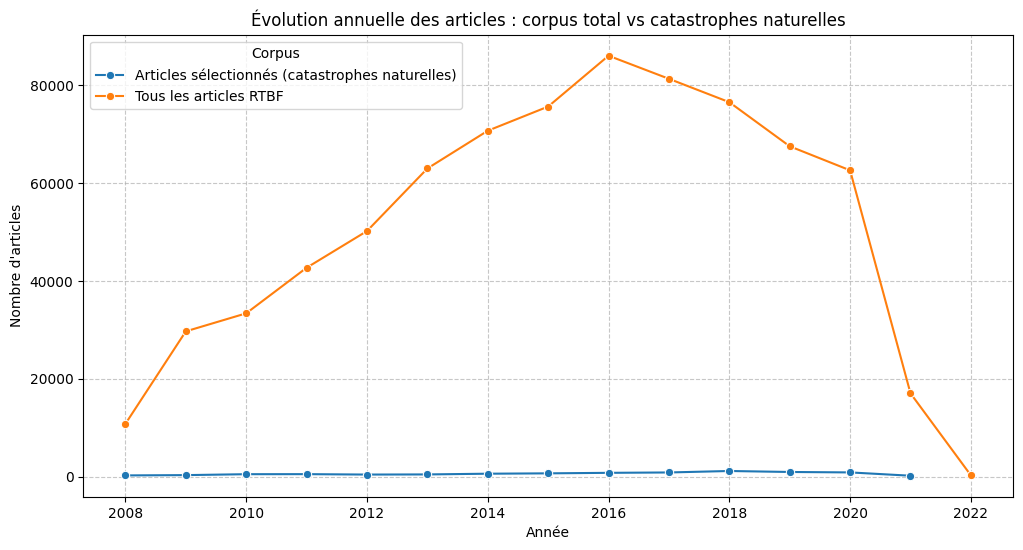

/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




    annee  proportion_pct
0    2008        2.616010
1    2009        1.154727
2    2010        1.593625
3    2011        1.267305
4    2012        0.910649
5    2013        0.768754
6    2014        0.894297
7    2015        0.932453
8    2016        0.941981
9    2017        1.090099
10   2018        1.549020
11   2019        1.459346
12   2020        1.430101
13   2021        1.290625


/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [16]:
articles_par_annee = (
    df_select_trie2
    .groupby("annee")
    .size()
    .reset_index(name="nombre_articles")
)
df_all["pub_date"] = pd.to_datetime(df_all["pub_date"])
df_all["annee"] = df_all["pub_date"].dt.year
# calcul du nombre d'articles par années avant le trie. 
articles_par_annee_avant_trie = (
    df_all
    .groupby("annee")
    .size()
    .reset_index(name="nombre_articles")
)
# renommage des colonnes. 
articles_par_annee["type"] = "Articles sélectionnés (catastrophes naturelles)"
articles_par_annee_avant_trie["type"] = "Tous les articles RTBF"
# concatenation des deux tableaux 
df_tendances = pd.concat(
    [articles_par_annee, articles_par_annee_avant_trie],
    ignore_index=True
)
# graph d'affichage des tendances. 
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_tendances, x="annee", y="nombre_articles", hue="type", marker="o")

plt.title("Évolution annuelle des articles : corpus total vs catastrophes naturelles")
plt.xlabel("Année")
plt.ylabel("Nombre d'articles")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Corpus")

# Sauvegarde statique immédiate
plt.savefig("evolution_articles.png", dpi=300, bbox_inches='tight')
plt.show()
graph = px.line(
    articles_par_annee,
    x="annee",
    y="nombre_articles",
    markers=True,
    title="Évolution annuelle des articles toutes catastrophes confondues."
)

graph.write_image("evolution_articles_selectionner.png", scale=2, width=1000, height=600)
graph.show()

# fusion des comptages par année
df_stats = pd.merge(
    articles_par_annee_avant_trie, 
    articles_par_annee, 
    on="annee", 
    suffixes=('_total', '_select')
)

# 2. Calcul du pourcentage annuel
df_stats['proportion_pct'] = (df_stats['nombre_articles_select'] / df_stats['nombre_articles_total']) * 100

# 3. Affichage du résultat pour votre rapport
print(df_stats[['annee', 'proportion_pct']])

# 4. Graphique de la tendance relative
graph_proportion = px.line(
    df_stats, 
    x="annee", 
    y="proportion_pct", 
    markers=True,
    title="Évolution de la part relative des catastrophes naturelles dans le corpus (%)",
    labels={"proportion_pct": "% du corpus total", "annee": "Année"}
)
graph_proportion.write_image("proportion_catastrophes.png", scale=2, width=1000, height=600)
graph_proportion.show()


In [17]:
tb=df_select_trie2['category'].unique()
pd.set_option('display.max_rows', None,'display.max_colwidth', None)
print(len(tb))
print(tb)
df_select_trie2.loc[df_select['category'] == '7 A LA UNE',
              ['title','categorie_alea']]

18
['BELGIQUE' 'MONDE' 'SOCIETE' nan 'REGIONS' 'CHRONIQUES' 'AU QUOTIDIEN'
 'ECONOMIE' 'MEDIAS' 'ETCETERA' 'OPINIONS' 'L INDISCRET' 'GENERAL'
 'TRANSVERSALES' 'LE 15 MINUTES' '7 A LA UNE' 'JEUDI EN PRIME' 'INSIDE']


,title,categorie_alea
312209,Alerte tempête: les coulisses de la météo - Le Tour d'Horloge - 7 à la Une,"(tempete,)"
484157,Ils sécurisent parcs et forêts — L'immersion de 7 à la Une,"(tempete,)"
644618,SOS inondations – L'envers du décor dans 7 à la Une,"(inondation,)"
664177,Des inventions anti-catastrophes – Alice's Map dans 7 à la Une,"(inondation,)"


In [ ]:
#df_select_trie2.loc[740873]

###  Analyse Statistique à deux niveaux 

In [18]:
# comptage des sous catégories 
stats_individuelles = (
    df_select_trie2["categorie_alea"]
    .explode()
    .value_counts()
)

print("--- Top 10 des catégories individuelles ---")
print(stats_individuelles.head(10))

--- Top 10 des catégories individuelles ---
categorie_alea
tempete             3337
inondation          2994
intemperies         2770
secheresse          2068
vague_de_chaleur    1156
Name: count, dtype: int64


In [19]:
stats_combinaisons = (
    df_select_trie2["categorie_alea"]
    .value_counts()
)

print("--- Top 10 des combinaisons de catégories ---")
print(stats_combinaisons.head(35))

--- Top 10 des combinaisons de catégories ---
categorie_alea
(tempete,)                                                          1655
(secheresse,)                                                       1410
(inondation,)                                                       1312
(intemperies,)                                                      1204
(vague_de_chaleur,)                                                  698
(intemperies, tempete)                                               528
(inondation, tempete)                                                491
(inondation, intemperies)                                            479
(inondation, intemperies, tempete)                                   401
(secheresse, vague_de_chaleur)                                       214
(inondation, secheresse)                                             111
(secheresse, tempete)                                                 96
(inondation, secheresse, vague_de_chaleur)                     

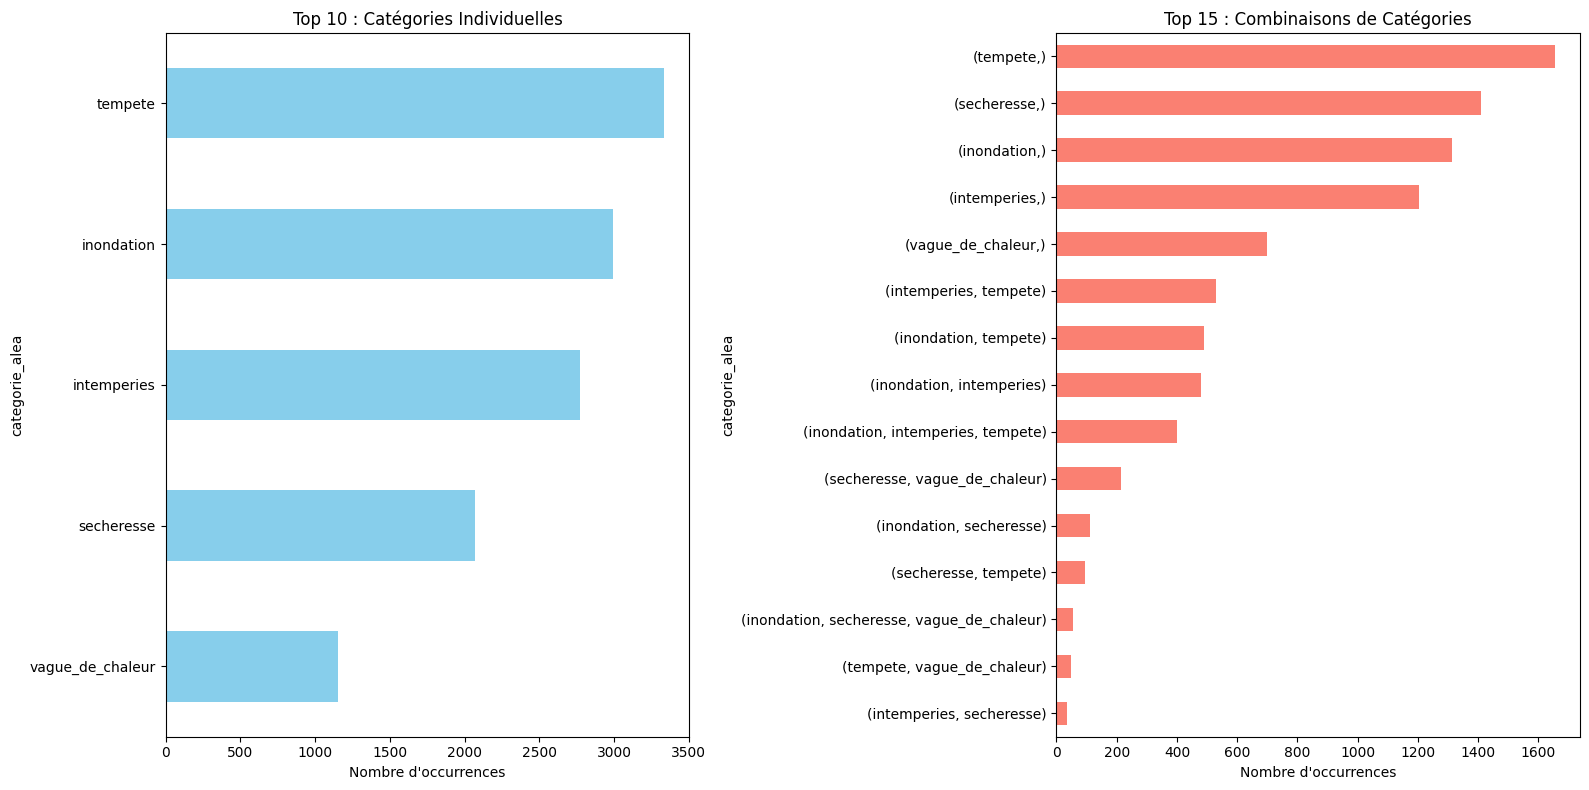

In [20]:



# 1. Calcul des données
# Top 10 Individuel 
top_solo = df_select_trie2["categorie_alea"].explode().value_counts().head(10)

# Top 15 Combinaisons 
top_combo = df_select_trie2["categorie_alea"].apply(tuple).value_counts().head(15)

# 2. Création de la figure (
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Graphique 1 : Individuel
top_solo.sort_values().plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title("Top 10 : Catégories Individuelles")
ax1.set_xlabel("Nombre d'occurrences")

# Graphique 2 : Combinaisons (Affichera les 15)
top_combo.sort_values().plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title("Top 15 : Combinaisons de Catégories")
ax2.set_xlabel("Nombre d'occurrences")

plt.tight_layout()
plt.show()


In [21]:
# comptage des grandes catégories 
stats_big_cat = df_select_trie2["big_cat"].value_counts().sort_index()
print(stats_big_cat)

big_cat
[chaleur]                 2322
[intemperies]             6070
[intemperies, chaleur]     566
Name: count, dtype: int64


In [22]:
# tableau croisé sous catégories et années 
df_exploded = df_select_trie2.explode("categorie_alea")
table_souscat_annee = pd.crosstab(
    df_exploded["annee"],
    df_exploded["categorie_alea"]
)

print(table_souscat_annee)



categorie_alea  inondation  intemperies  secheresse  tempete  vague_de_chaleur
annee                                                                         
2008                   101          121          31      142                 6
2009                   142          119          75      136                17
2010                   252          158          73      159                63
2011                   241          175         111      176                29
2012                   189          154          74      189                45
2013                   171          166          62      214                46
2014                   230          246          89      258                41
2015                   227          210         166      282               108
2016                   305          299         144      328                67
2017                   271          242         228      352                91
2018                   319          328         370 

In [23]:
from itertools import combinations
import pandas as pd

# Liste de toutes les catégories possibles
all_cats = sorted(
    set(cat for cats in df_select_trie2["categorie_alea"] for cat in cats)
)

# Initialisation de la matrice
cooc_matrix = pd.DataFrame(
    0,
    index=all_cats,
    columns=all_cats
)

# Remplissage
for cats in df_select_trie2["categorie_alea"]:
    for c1, c2 in combinations(cats, 2):
        cooc_matrix.loc[c1, c2] += 1
        cooc_matrix.loc[c2, c1] += 1

# Diagonale = fréquence individuelle
for cat in all_cats:
    cooc_matrix.loc[cat, cat] = (
        df_select_trie2["categorie_alea"]
        .apply(lambda x: cat in x)
        .sum()
    )

cooc_matrix


,inondation,intemperies,secheresse,tempete,vague_de_chaleur
inondation,2994,953,260,959,131
intemperies,953,2770,122,976,67
secheresse,260,122,2068,189,336
tempete,959,976,189,3337,121
vague_de_chaleur,131,67,336,121,1156


In [ ]:
#pip install networkx

Afin d’analyser les interactions entre les différents aléas climatiques, un réseau de co-occurrence a été construit à partir des articles multi-étiquetés. Les nœuds représentent les catégories d’aléas, tandis que les arêtes pondérées indiquent la fréquence de leur co-présence au sein d’un même article. Cette approche permet de mettre en évidence les associations structurelles entre événements climatiques extrêmes, au-delà de leur fréquence individuelle.

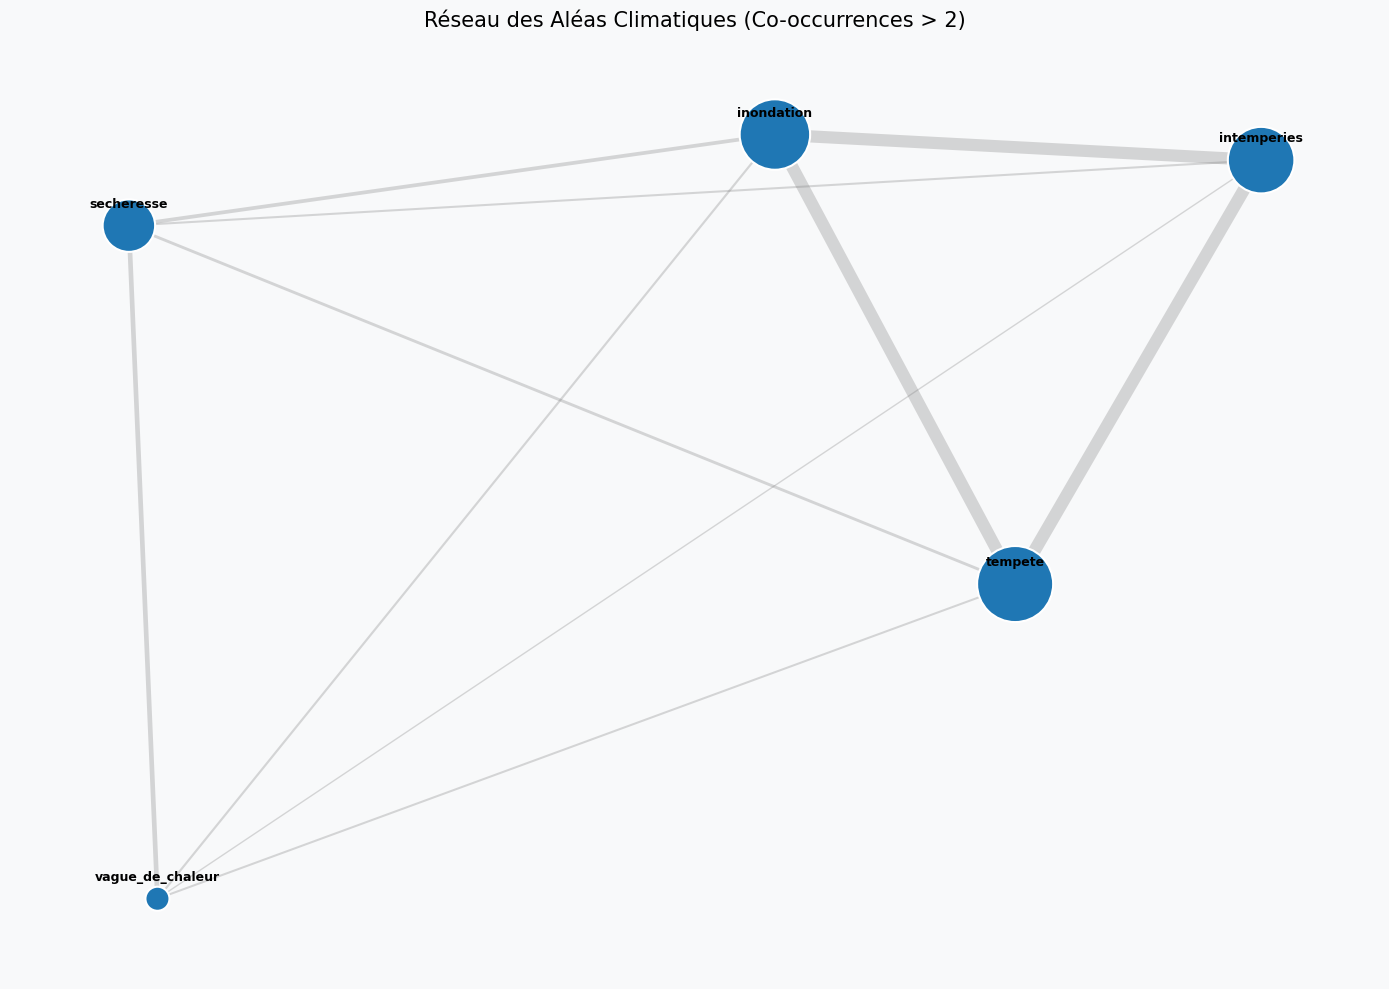

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration du graphe et filtrage
G = nx.Graph()
threshold = 2  # Ignorer les liens trop faibles pour plus de clarté

for c1, c2 in combinations(all_cats, 2):
    weight = cooc_matrix.loc[c1, c2]
    if weight > threshold:
        G.add_edge(c1, c2, weight=weight)

# Ajouter les nœuds isolés (ceux qui n'ont pas passé le seuil de liens)
G.add_nodes_from(all_cats)

# 2. Calcul des paramètres visuels
# Taille des nœuds : basée sur la diagonale (fréquence totale)
counts = np.array([cooc_matrix.loc[n, n] for n in G.nodes()])
# Normalisation pour que les tailles restent raisonnables (entre 300 et 3000)
node_sizes = 300 + (counts - counts.min()) / (counts.max() - counts.min() + 1) * 2700

# Épaisseur des liens : normalisée
weights = [G[u][v]['weight'] for u, v in G.edges()]
if weights:
    edge_widths = 1 + (np.array(weights) - min(weights)) / (max(weights) - min(weights) + 1) * 8
else:
    edge_widths = 1

# 3. Layout et Dessin
plt.figure(figsize=(14, 10), facecolor='#f8f9fa')
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Dessin des composants
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#1f77b4', edgecolors='white', linewidths=1.5)

# Labels avec un léger décalage vertical pour plus de lisibilité
label_pos = {k: [v[0], v[1] + 0.04] for k, v in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=9, font_family='sans-serif', font_weight='bold')

plt.title("Réseau des Aléas Climatiques (Co-occurrences > {})".format(threshold), fontsize=15, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()


In [41]:

counts = (
    df_select_trie2.explode("categorie_alea")
    .groupby(["annee", "categorie_alea"])
    .size()
    .reset_index(name="n")
)

# 2. Nombre total d’articles uniques par année (votre code original)
total_par_annee = (
    df_select_trie2
    .groupby("annee")
    .size()
    .reset_index(name="total_articles")
)

# 3. Fusion et calcul du pourcentage
counts_pct = counts.merge(
    total_par_annee,
    on="annee",
    how="left"
)

counts_pct["pct"] = (
    counts_pct["n"] / counts_pct["total_articles"] * 100
)

# 4. Visualisation
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Création du graphique avec un axe Y secondaire
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 2. Ajout des barres (Pourcentages par catégorie)
# On boucle sur chaque catégorie pour garder les couleurs de Plotly Express
categories = counts_pct['categorie_alea'].unique()
for cat in categories:
    df_cat = counts_pct[counts_pct['categorie_alea'] == cat]
    fig.add_trace(
        go.Bar(
            x=df_cat['annee'], 
            y=df_cat['pct'], 
            name=cat,
            hovertemplate="Catégorie: " + cat + "<br>Part: %{y:.2f}%<br>Année: %{x}"
        ),
        secondary_y=False,
    )

# 3. Ajout de la courbe (Volume total d'articles par an)
fig.add_trace(
    go.Scatter(
        x=total_par_annee['annee'], 
        y=total_par_annee['total_articles'], 
        name="Volume total articles",
        mode='lines+markers',
        line=dict(color='black', width=3),
        hovertemplate="Total articles: %{y}<br>Année: %{x}"
    ),
    secondary_y=True,
)

# 4. Mise en page
fig.update_layout(
    title_text="Part des aléas (%) et Volume global d'articles par an",
   font=dict(size=20), legend=dict( title="Catégories d'aléas", orientation="h", yanchor="bottom", y=1.15, xanchor="center", x=0.5, font=dict(size=16), title_font=dict(size=17), bgcolor="rgba(255,255,255,0.85)", bordercolor="black", borderwidth=1 ), margin=dict(t=140), barmode='group' )

# Configuration des titres des axes
fig.update_yaxes(title_text="(%) des articles articles sélectionnés par cat ", secondary_y=False)
fig.update_yaxes(title_text="Nombre total d'articles (unité)", secondary_y=True)
fig.update_xaxes(title_text="Année")
fig.write_image("evol_prop_art_sel_catt.png", scale=2, width=850, height=600)
fig.show()




/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [38]:
# 1. Préparation des données
# A. Comptage des occurrences par catégorie
counts = (
    df_select_trie2.explode("categorie_alea")
    .groupby(["annee", "categorie_alea"])
    .size()
    .reset_index(name="nb_articles")
)

# B. Calcul du volume GLOBAL (df_all) pour la courbe de fond et la normalisation
total_global = df_all.groupby("annee").size().reset_index(name="total_rtbf")

# C. Fusion et calcul du pourcentage relatif au corpus global
df_evolution = counts.merge(total_global, on="annee", how="left")
df_evolution["part_mediatique"] = (df_evolution["nb_articles"] / df_evolution["total_rtbf"]) * 100



fig_evol = make_subplots(specs=[[{"secondary_y": True}]])

# 3. Ajout des lignes de part médiatique (%) par catégorie (Axe Y Gauche)
categories = df_evolution['categorie_alea'].unique()
for cat in categories:
    df_cat = df_evolution[df_evolution['categorie_alea'] == cat]
    fig_evol.add_trace(
        go.Scatter(
            x=df_cat['annee'], 
            y=df_cat['part_mediatique'], 
            name=f"% {cat}",
            mode='lines+markers'
        ),
        secondary_y=False,
    )

# 4. Ajout de la courbe du Volume GLOBAL du corpus (Axe Y Droit)
# On utilise total_global calculé à partir de df_all
fig_evol.add_trace(
    go.Scatter(
        x=total_global['annee'], 
        y=total_global['total_rtbf'], 
        name="Volume total corpus (df_all)",
        mode='lines+markers',
        line=dict(color='gray', width=3, dash='dot'), # Gris pointillé pour ne pas surcharger
        opacity=0.5
    ),
    secondary_y=True,
)

# 5. Mise en page et titres
fig_evol.update_layout(
    title_text="Évolution de la part médiatique vs Volume global du corpus RTBF",
    hovermode="x unified",
    legend_title="Indicateurs",
    template="plotly_white", 
    font=dict(size=20), legend=dict( title="Catégories d'aléas", orientation="h", yanchor="bottom", y=1.15, xanchor="center", x=0.5, font=dict(size=16), title_font=dict(size=17), bgcolor="rgba(255,255,255,0.85)", bordercolor="black", borderwidth=1 ), margin=dict(t=140), barmode='group' )


# Configuration des axes
fig_evol.update_yaxes(title_text="Part du corpus global (%)", secondary_y=False)
fig_evol.update_yaxes(title_text="Nombre total d'articles dans le corpus (unité)", secondary_y=True)
fig_evol.update_xaxes(title_text="Année")

# Exportation et affichage
fig_evol.write_image("evol_global_rtbf.png", scale=2, width=850, height=600)
fig_evol.show()


/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




le niveau bas d'articles est du au fait qu'en 2021 nous avons très peut d'articles dans le corpus. 

In [30]:
df_flat = df_select_trie2.explode("big_cat")

# Crée ensuite le tableau croisé
table_bigcat_annee = pd.crosstab(df_flat["annee"], df_flat["big_cat"])
print(table_bigcat_annee)

big_cat  chaleur  intemperies
annee                        
2008          35          252
2009          82          281
2010         113          438
2011         132          432
2012         105          372
2013         100          403
2014         116          546
2015         250          518
2016         197          647
2017         288          667
2018         490          773
2019         489          589
2020         412          565
2021          79          153


In [31]:
import plotly.io as pio
pio.renderers.default = "browser"
# 1. Préparation des données (Courbes de catégories)
df_flat = df_select_trie2.explode("big_cat")
counts1 = df_flat.groupby(["annee", "big_cat"]).size().reset_index(name="n")
counts1["pourcentage"] = counts1.groupby("annee")["n"].transform(lambda x: (x / x.sum()) * 100)

# 2. Préparation des données (Courbe du volume total)
total_par_annee = df_select_trie2.groupby("annee").size().reset_index(name="total_vol")

# 3. Création du graphique à double axe
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Ajout des COURBES (Pourcentages par catégorie)
for cat in counts1["big_cat"].unique():
    df_sub = counts1[counts1["big_cat"] == cat]
    fig.add_trace(
        go.Scatter(
            x=df_sub["annee"],
            y=df_sub["pourcentage"],
            name=cat,
            mode='lines+markers', # Lignes et points
            line=dict(width=2),
            hovertemplate=f"<b>{cat}</b><br>Part: %{{y:.1f}}%<br>Année: %{{x}}<extra></extra>"
        ),
        secondary_y=False,
    )

# Ajout de la courbe du VOLUME TOTAL (en gris ou noir pour le contraste)
fig.add_trace(
    go.Scatter(
        x=total_par_annee["annee"],
        y=total_par_annee["total_vol"],
        name="Volume total articles",
        mode='lines+markers',
        line=dict(color='black', width=4, dash='dot'), # Ligne pointillée épaisse pour bien la distinguer
        marker=dict(size=10, symbol='diamond'),
        hovertemplate="Total articles: %{y}<br>Année: %{x}"
    ),
    secondary_y=True,
)

# 4. Mise en page et titres
fig.update_layout(
    title_text="Évolution de la part des aléas (%) vs Volume total d'articles",
    xaxis=dict(title="Année", dtick=1),
    legend_title="Catégories",
    hovermode="x unified",
    width=1000,
    height=500,
    template="plotly_white",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig.update_yaxes(title_text="Part des catégories (%)", secondary_y=False, range=[0, 105])
fig.update_yaxes(title_text="Nombre total d'articles (Volume)", secondary_y=True)

# Exportation
fig.write_image("big_curves.png", scale=2, width=850, height=450)
fig.show()

/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




#### Analyse  des aléas par grandes catégories , sous catégories et Category la colonne qui reprends les revues d'information. 
 cette  partie de l'analyse nous permets de voir, dans quelle catégorie de publications(ou émission) nos aléas sont abordées et dans quelle proportion.

In [119]:
# 1. On explose CATEGORY
df_flat = df_select_trie2.explode("category")

# 2. On explose AUSSI BIG_CAT
df_flat = df_flat.explode("big_cat")

# 3. Regroupement
counts2 = df_flat.groupby(["category", "big_cat"]).size().reset_index(name="n")

# 4. Tri des données (important pour voir les plus gros volumes à gauche)
counts2 = counts2.sort_values("n", ascending=False)

fig3 = px.bar(
    counts2,
    x="category",
    y="n",
    color="big_cat",
    title="Contexte de traitement des grandes catégories d'aléas ",
    labels={
        "n": "Nombre d'articles", 
        "category": "contexte", 
        "big_cat": "Domaine d'aléa"
    },
    barmode="group"  # MODIFICATION ICI : les barres sont maintenant côte à côte
)

# Amélioration de la lisibilité
fig3.update_layout(
    xaxis_tickangle=-45,
    legend_title="Grande catégorie",
    margin=dict(b=100), # Ajoute de l'espace en bas pour les noms inclinés
    template="plotly_white"
)
fig3.write_image("contexte.png", scale=2, width=850, height=450)
fig3.show()

/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/plotly/io/_kaleido.py:528: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




constant 1 forte présence des aléas ou niveau mondial  et regional que national.  

In [ ]:
#pip install dash_bootstrap_components 

In [ ]:
#pip install clean-text

## application du model LDA  sur l'ensemble du corpus trié 
####  clean text 
Nous allons utiliser la fonction **clean-all** du package **clean_text**  qui permet de nettoyer du texte pour des modèles comme le LDA. 
par la suite un retrait de stopwords et la tokenisation sera appliqué 

In [15]:
import re

# Liste des jours en français (minuscules)
jours_regex = r'lundi|mardi|mercredi|jeudi|vendredi|samedi|dimanche'

# Application sur la colonne déjà nettoyée
df_select_trie2['test_preprocessed'] = df_select_trie2['test_preprocessed'].str.replace(
    jours_regex, 'week', flags=re.IGNORECASE, regex=True
)
from cleantext import clean
text_clean = df_select_trie2['test_preprocessed'].apply(
    lambda x: clean(x, 
                   fix_unicode=True,
                   to_ascii=False,  # On conserve les accents
                   lower=True,
                   no_line_breaks=True,
                   no_urls=True,
                   no_emails=True,
                   no_phone_numbers=True,
                   no_numbers=False,
                   no_digits=False,
                   no_currency_symbols=False,
                   no_punct=False)  # On conserve la ponctuation pour l'instant  
)

/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/3091421022.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2['test_preprocessed'] = df_select_trie2['test_preprocessed'].str.replace(
Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


#### Tokenisation et retrait de stopwords 
 nous allos créer une fonction qui vas nous permettre à la fois de tokeniser , retirer les stopwords et lemmatiser 

In [16]:
import spacy # package qui permet la lemmatisation. 
nlp = spacy.load("fr_core_news_sm") #  chargement du model spaCy français 
stop_words_fr = stopwords.words('french') #retrait des stops words en français 
# creation d'une fonction qui nous permet de découper  le texte en tokens , supprime les ponctuations  et les stopwords. 
def preprocess(texts):
    processed_texts = []
    
    for text in texts:
        #Tokenisation (avec accents, suppression des tokens < 3 caractères)
        tokens = simple_preprocess(text, deacc=False, min_len=3)
        
        # Suppression des stopwords
        tokens = [word for word in tokens if word not in stop_words_fr]
        
        #Lemmatisation avec spaCy
        doc = nlp(" ".join(tokens))  # reconvertir la liste de mots en texte pour spaCy
        lemmas = [token.lemma_ for token in doc if token.lemma_ not in stop_words_fr and not token.is_punct]
        
        #Stocker le texte traité
        processed_texts.append(lemmas)
    
    return processed_texts

# nettoyage du corpus  en retirant  les stop_words et en le tokenisant. 
text_token = preprocess(text_clean)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
 

In [ ]:
# Afficher les 5 premiers documents après tokenisation. 
"""print("=== 5 premiers documents ===")
for i, doc in enumerate(text_token[:5]):
    print(f"Document {i}: {doc}")
    print(f"Nombre de tokens: {len(doc)}")
    print("---")"""

#### Formation des bi et trigrammes  plus triage nominal 
Nous souhaitons identifier les bigrammes et les trigrammes afin de les concaténer et de les considérer comme un seul mot. Les bigrammes sont des expressions de deux mots, par exemple « réseaux sociaux », où « social » et « médias » sont plus susceptibles d'apparaître ensemble que séparément. De même, les trigrammes sont des expressions de trois mots qui sont plus susceptibles d'apparaître ensemble, par exemple « Procter & Gamble ». Nous utilisons le score d'information mutuelle ponctuelle pour identifier les bigrammes et les trigrammes significatifs à concaténer. Nous filtrons également les bigrammes et les trigrammes avec les filtres (nom/adjectif, nom) et (nom/adjectif, tous types, nom/adjectif), car ce sont des structures courantes qui indiquent des n-grammes de type nominal. Cela permet au modèle LDA de mieux regrouper les sujets

In [17]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

# Détection des bigrammes
bigram = Phrases(text_token, min_count=5, threshold=10)  
bigram_mod = Phraser(bigram)

# Détection des trigrammes à partir des bigrammes
trigram = Phrases(bigram[text_token], threshold=10)
trigram_mod = Phraser(trigram)

# Application au corpus
texts_bigrams = [bigram_mod[doc] for doc in text_token]
texts_trigrams = [trigram_mod[bigram_mod[doc]] for doc in text_token]

 Nous  filtrons par la suite les n-grammes par type grammatical (POS) pour ne garder que les bigrammes ou trigrammes de structure nominale.
 Une structure nominale (ou groupe nominal) est une expression centrée autour d’un nom (un substantif).
Autrement dit, c’est un ensemble de mots dont le noyau est un nom, éventuellement accompagné d’adjectifs ou de compléments.

In [18]:
import spacy
nlp = spacy.load("fr_core_news_sm")

def filter_ngrams_by_pos(texts):
    filtered_texts = []
    for doc in texts:
        spacy_doc = nlp(" ".join(doc))
        new_tokens = []
        for token in spacy_doc:
            # On garde les noms et adjectifs
            if token.pos_ in ['NOUN', 'ADJ']:
                new_tokens.append(token.text)
        filtered_texts.append(new_tokens)
    return filtered_texts

texts_filtered = filter_ngrams_by_pos(texts_trigrams)


In [68]:
# creation d'un dictionnaire qui attribut à chaque mot un identifiant unique. 
dictionary = corpora.Dictionary(texts_filtered)

In [69]:
# transforme le texte en sac de mots(bag-of-words)  car le lda ignore l'ordre des mots et le contexte.
# ajout de ce bag-of-words dans le corpus. 
corpus = [dictionary.doc2bow(text) for text in texts_filtered]

Maintenat nous allons utiliser  mesure cohérence_Cv(Cohérence cross validation) pour trouver le nombre de topics parfaits pour notre modèle. 
Cette metrique mesure de la qualité des sujets : Un sujet est considéré comme "cohérent" si ses mots les plus probables sont sémantiquement liés et ont du sens lorsqu'ils sont interprétés ensemble par un humain. 

In [ ]:
#pip install matplotlib

## Analyse de stabilité du modèle 

=== VÉRIFICATION CONVERGENCE (checkpoints) ===
  passes= 5 | perplexité=5983.4274 | temps cumulé=22s
  passes=10 | perplexité=5599.7314 | temps cumulé=47s
  passes=15 | perplexité=5427.7208 | temps cumulé=77s
  passes=20 | perplexité=5334.6956 | temps cumulé=111s
  passes=25 | perplexité=5276.0383 | temps cumulé=149s
  passes=30 | perplexité=5235.0764 | temps cumulé=190s
  passes=50 | perplexité=5147.7095 | temps cumulé=246s
  passes=60 | perplexité=5123.1641 | temps cumulé=312s
  passes=70 | perplexité=5104.5327 | temps cumulé=386s
  passes=80 | perplexité=5088.5780 | temps cumulé=468s
  passes=100 | perplexité=5065.7062 | temps cumulé=564s
  passes=120 | perplexité=5051.3547 | temps cumulé=677s
  passes=150 | perplexité=5037.2840 | temps cumulé=812s
  passes=170 | perplexité=5030.5983 | temps cumulé=964s
  passes=200 | perplexité=5023.8116 | temps cumulé=1142s
  passes=220 | perplexité=5020.2875 | temps cumulé=1331s
  passes=250 | perplexité=5016.3550 | temps cumulé=1546s
  passes=30

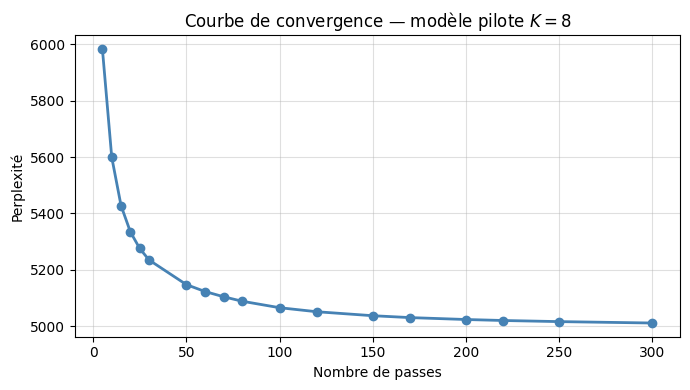

Figure → lda_convergence_curve.png

Variation sur les 3 derniers checkpoints : 0.1781%
Convergence : ✓ OUI

✓ Convergence atteinte — passes optimal = 170

=== SENSIBILITÉ : 33 modèles | passes=170 | iter=1000 ===

Alpha=symmetric    | K= 3 | Cv=0.3528 | 194s/modèle | total=3.2min
Alpha=symmetric    | K= 4 | Cv=0.4009 | 165s/modèle | total=6.0min
Alpha=symmetric    | K= 5 | Cv=0.4052 | 167s/modèle | total=8.8min
Alpha=symmetric    | K= 6 | Cv=0.4060 | 166s/modèle | total=11.5min
Alpha=symmetric    | K= 7 | Cv=0.4149 | 165s/modèle | total=14.3min
Alpha=symmetric    | K= 8 | Cv=0.4171 | 165s/modèle | total=17.0min
Alpha=symmetric    | K= 9 | Cv=0.4012 | 170s/modèle | total=19.9min
Alpha=symmetric    | K=10 | Cv=0.3992 | 173s/modèle | total=22.8min
Alpha=symmetric    | K=11 | Cv=0.3791 | 176s/modèle | total=25.7min
Alpha=symmetric    | K=12 | Cv=0.3961 | 177s/modèle | total=28.6min
Alpha=symmetric    | K=13 | Cv=0.3907 | 182s/modèle | total=31.7min
Alpha=asymmetric   | K= 3 | Cv=0.3452 | 1

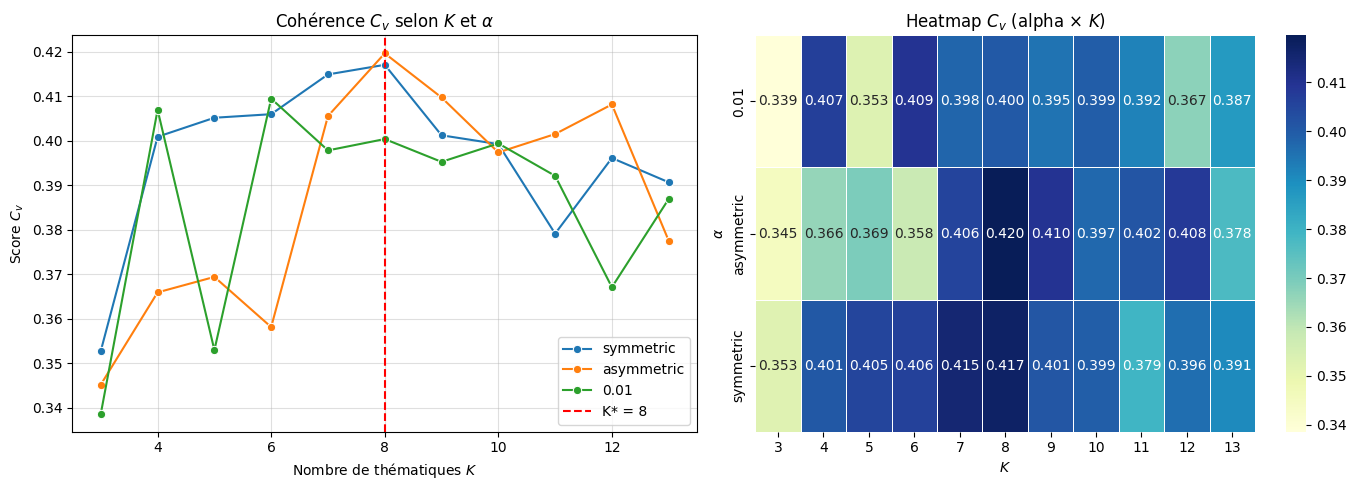

Figure → lda_sensitivity.png


In [60]:
import logging
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models.ldamulticore import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

# ── Paramètres ────────────────────────────────────────────────────────────────
k_range     = range(3, 14)      # K de 3 à 13 = 11 valeurs
passes      = 20                # budget passes
iterations  = 1000
alphas      = ['symmetric', 'asymmetric']
alpha_fixed = 0.01
seed        = 123
workers     = 7

# ── Fonction helper alpha ─────────────────────────────────────────────────────
def build_alpha(a, k):
    if isinstance(a, float):
        return np.full(k, a)
    return a

# ── ÉTAPE 1 : Vérification convergence (version optimisée) ───────────────────
# Au lieu de 30 modèles séquentiels (très coûteux),
# on entraîne UN SEUL modèle avec passes_max passes
# et on trace la perplexité à intervalles réguliers (5, 10, 15, 20, 25, 30)
# → gain de temps : facteur ~8x vs version naïve

def check_convergence_fast(corpus, dictionary, k_pilot=8,
                           checkpoints=[5, 10, 15, 20, 25, 30, 50, 60 , 70, 80, 100, 120, 150, 170, 200, 220, 250, 300],
                           seed=123, workers=7):
    """
    Vérifie la convergence en entraînant des modèles uniquement aux checkpoints.
    Beaucoup plus rapide que d'entraîner passes=1, 2, 3...N séquentiellement.
    """
    print("=== VÉRIFICATION CONVERGENCE (checkpoints) ===")
    perplexities = []
    t0 = time.time()

    for p in checkpoints:
        m = LdaMulticore(
            corpus=corpus,
            num_topics=k_pilot,
            id2word=dictionary,
            passes=p,
            iterations=400,
            workers=workers,
            random_state=seed,
            alpha='symmetric',
            eval_every=None,
        )
        perp = np.exp(-m.log_perplexity(corpus))
        perplexities.append((p, perp))
        elapsed = time.time() - t0
        print(f"  passes={p:2d} | perplexité={perp:.4f} | temps cumulé={elapsed:.0f}s")

    # Tracé
    px = [x[0] for x in perplexities]
    py = [x[1] for x in perplexities]

    plt.figure(figsize=(7, 4))
    plt.plot(px, py, marker='o', color='steelblue', linewidth=2)
    plt.xlabel("Nombre de passes")
    plt.ylabel("Perplexité")
    plt.title(f"Courbe de convergence — modèle pilote $K={k_pilot}$")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("lda_convergence_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure → lda_convergence_curve.png\n")

    # Détection plateau : variation < 0.5% sur les 3 derniers checkpoints
    if len(py) >= 3:
        recent    = py[-3:]
        variation = (max(recent) - min(recent)) / max(recent)
        converged = variation < 0.005
        print(f"Variation sur les 3 derniers checkpoints : {variation*100:.4f}%")
        print(f"Convergence : {'✓ OUI' if converged else '✗ NON — augmenter passes'}\n")
        return converged, px, py
    return False, px, py

converged, px, py = check_convergence_fast(
    corpus, dictionary, k_pilot=8,
    checkpoints=[5, 10, 15, 20, 25, 30, 50, 60 , 70, 80, 100, 120, 150, 170, 200, 220, 250, 300]
)

# Trouver le checkpoint minimal où la convergence est atteinte
passes_optimal = px[-1]  # par défaut : dernier checkpoint
for i in range(2, len(py)):
    recent    = py[i-2:i+1]
    variation = (max(recent) - min(recent)) / max(recent)
    if variation < 0.005:
        passes_optimal = px[i]
        break

if not converged:
    passes_optimal = px[-1]  # plafonné au dernier checkpoint
    print(f"⚠ Convergence non atteinte — passes plafonné à {passes_optimal}\n")
else:
    print(f"✓ Convergence atteinte — passes optimal = {passes_optimal}\n")

passes = passes_optimal

# ── ÉTAPE 2 : Analyse de sensibilité ─────────────────────────────────────────
print(f"=== SENSIBILITÉ : {len(list(k_range))*3} modèles | passes={passes} | iter={iterations} ===\n")

results    = []
best_score = -np.inf
best_model = None
best_params = {}
t_start    = time.time()

all_alphas = alphas + [alpha_fixed]

for a in all_alphas:
    for k in k_range:
        t_model = time.time()
        alpha_param = build_alpha(a, k)
        label = str(a)

        model = LdaMulticore(
            corpus=corpus,
            num_topics=k,
            id2word=dictionary,
            passes=passes,
            iterations=iterations,
            workers=workers,
            random_state=seed,
            alpha=alpha_param,
            eval_every=None,
        )

        cv = CoherenceModel(
            model=model,
            texts=texts_filtered,
            dictionary=dictionary,
            coherence='c_v'
        ).get_coherence()

        elapsed_model = time.time() - t_model
        elapsed_total = time.time() - t_start
        print(f"Alpha={label:12s} | K={k:2d} | Cv={cv:.4f} | "
              f"{elapsed_model:.0f}s/modèle | total={elapsed_total/60:.1f}min")

        results.append({"k": k, "alpha": label, "coherence": cv})

        if cv > best_score:
            best_score  = cv
            best_model  = model
            best_params = {"k": k, "alpha": label, "coherence": round(cv, 4)}

# ── Résultats ─────────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
total_time = (time.time() - t_start) / 60

print(f"\n─── MEILLEUR MODÈLE ({'─'*40}")
for key, val in best_params.items():
    print(f"  {key:12s}: {val}")
print(f"  {'temps total':12s}: {total_time:.1f} minutes")

best_model.save("best_lda_model")
print("Modèle sauvegardé → best_lda_model")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="k", y="coherence", hue="alpha",
             marker="o", ax=axes[0])
axes[0].axvline(best_params["k"], color="red", linestyle="--",
                label=f"K* = {best_params['k']}")
axes[0].set_title("Cohérence $C_v$ selon $K$ et $\\alpha$")
axes[0].set_xlabel("Nombre de thématiques $K$")
axes[0].set_ylabel("Score $C_v$")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

pivot = df.pivot(index="alpha", columns="k", values="coherence").round(4)
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Heatmap $C_v$ (alpha × $K$)")
axes[1].set_xlabel("$K$")
axes[1].set_ylabel("$\\alpha$")

plt.tight_layout()
plt.savefig("lda_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure → lda_sensitivity.png")


Corpus : 8,958 docs | Échantillon : 4,479 (50%)
Config : 100 reps | passes=10 | iter=50
Workers : 8 jobs × 1 = 8 threads
Timeout : 15 min/job | Checkpoint : toutes les 10 reps

Reps à faire : 100



Batches: 100%|██████████| 13/13 [2:10:18<00:00, 601.44s/batch] 



Temps réel : 2.17h
Réplications valides : 100/100

K moyen         : 7.53
Std             : 2.25
K le + fréquent : 5
Stabilité       : ⚠ INSTABLE

Fréquence K optimaux :
k
5     26
6     16
7     13
8     10
9     15
10     6
11     7
12     7


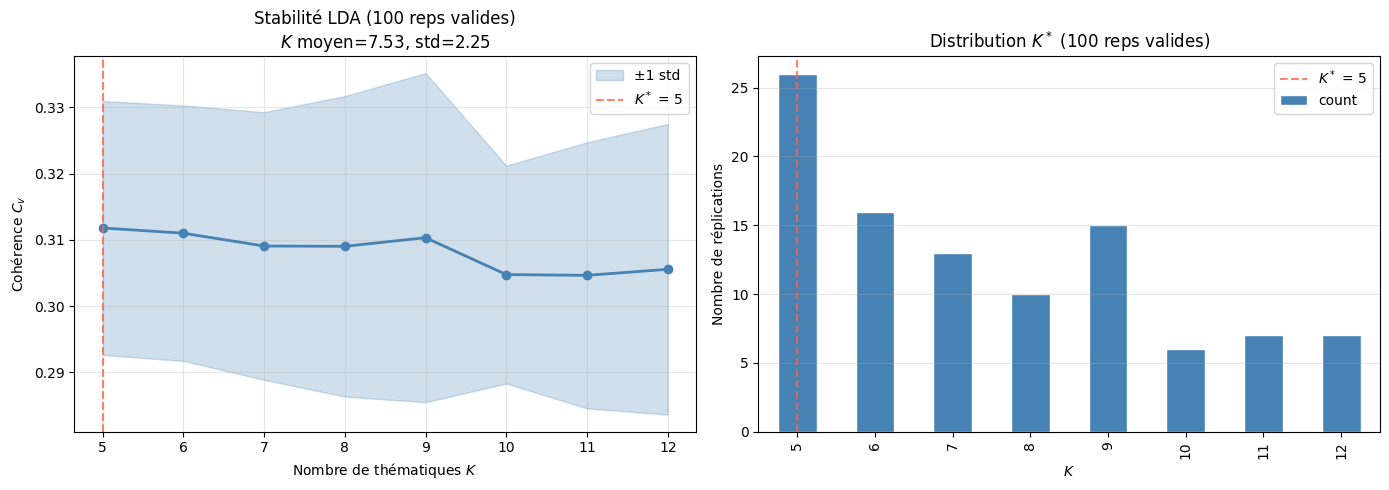

Figure → lda_stability.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models.ldamulticore import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import multiprocessing as mp
import logging, time, os

logging.basicConfig(level=logging.WARNING)

# ─── Paramètres ───────────────────────────────────────────────────────────────
n_rep        = 100
sample_ratio = 0.5
replace      = False
k_range      = [5, 6, 7, 8, 9, 10, 11, 12]

best_alpha  = "asymmetric"
best_passes = 10
best_iter   = 50

PHYSICAL_CORES = mp.cpu_count() // 2
JOBLIB_JOBS    = PHYSICAL_CORES
LDA_WORKERS    = 1
os.remove("lda_stability_checkpoint.csv")
SAVE_EVERY     = 10          # sauvegarde toutes les 10 reps
CHECKPOINT     = "lda_stability_checkpoint.csv"
TIMEOUT_SEC    = 900         # 15 min max par job — tue les jobs bloqués

n           = len(texts_filtered)
sample_size = int(n * sample_ratio)

print(f"Corpus : {n:,} docs | Échantillon : {sample_size:,} ({sample_ratio*100:.0f}%)")
print(f"Config : {n_rep} reps | passes={best_passes} | iter={best_iter}")
print(f"Workers : {JOBLIB_JOBS} jobs × {LDA_WORKERS} = {JOBLIB_JOBS} threads")
print(f"Timeout : {TIMEOUT_SEC//60} min/job | Checkpoint : toutes les {SAVE_EVERY} reps\n")

# ─── Reprendre depuis checkpoint si existant ──────────────────────────────────
completed_reps = set()
all_results_saved = []

if os.path.exists(CHECKPOINT):
    df_ckpt = pd.read_csv(CHECKPOINT)
    completed_reps = set(df_ckpt["replication"].unique())
    all_results_saved = df_ckpt.to_dict("records")
    print(f"Checkpoint trouvé : {len(completed_reps)} reps déjà complètes → reprise\n")

reps_todo = [r for r in range(n_rep) if (r + 1) not in completed_reps]
print(f"Reps à faire : {len(reps_todo)}\n")

# ─── Fonction de travail avec timeout interne ─────────────────────────────────
def run_replication(r: int):
    try:
        rng = np.random.default_rng(seed=r)
        idx = rng.choice(n, size=sample_size, replace=replace)

        sub_texts  = [texts_filtered[i] for i in idx]
        sub_corpus = [corpus[i]         for i in idx]

        rep_results = []
        for k in k_range:
            lda = LdaMulticore(
                corpus=sub_corpus,
                id2word=dictionary,
                num_topics=k,
                passes=best_passes,
                iterations=best_iter,
                alpha=best_alpha,
                random_state=r,
                workers=LDA_WORKERS,
                minimum_probability=0.0,
                eval_every=None,
            )
            coh = CoherenceModel(
                model=lda,
                texts=sub_texts,
                dictionary=dictionary,
                coherence="c_v",
                processes=1,
            ).get_coherence()

            rep_results.append({"replication": r + 1, "k": k, "coherence": coh})

        return rep_results

    except Exception as e:
        # Job échoué → retourne liste vide, pas de blocage
        return [{"replication": r + 1, "k": k, "coherence": np.nan}
                for k in k_range]

# ─── Boucle par batches avec sauvegarde progressive ───────────────────────────
t0          = time.time()
all_results = list(all_results_saved)
batch_size  = JOBLIB_JOBS

for batch_start in tqdm(range(0, len(reps_todo), batch_size),
                        desc="Batches", unit="batch"):

    batch = reps_todo[batch_start : batch_start + batch_size]

    try:
        batch_results = Parallel(
            n_jobs=len(batch),
            backend="loky",
            timeout=TIMEOUT_SEC,    # ← tue tout job > 15 min
        )(delayed(run_replication)(r) for r in batch)

    except Exception as e:
        print(f"\n⚠ Batch {batch_start//batch_size + 1} timeout/erreur : {e}")
        # Récupère ce qui a été fait, ignore le reste
        batch_results = [[{"replication": r+1, "k": k, "coherence": np.nan}
                          for k in k_range] for r in batch]

    for rep_rows in batch_results:
        all_results.extend(rep_rows)

    # Sauvegarde progressive
    if (batch_start // batch_size + 1) % (SAVE_EVERY // batch_size + 1) == 0:
        pd.DataFrame(all_results).to_csv(CHECKPOINT, index=False)

# Sauvegarde finale
pd.DataFrame(all_results).to_csv(CHECKPOINT, index=False)
elapsed_h = (time.time() - t0) / 3600
print(f"\nTemps réel : {elapsed_h:.2f}h")

# ─── Analyse (ignore les NaN des jobs échoués) ────────────────────────────────
df_res = pd.DataFrame(all_results).dropna(subset=["coherence"])

n_valid = df_res["replication"].nunique()
print(f"Réplications valides : {n_valid}/{n_rep}")

peaks  = df_res.loc[df_res.groupby("replication")["coherence"].idxmax()]
freq_k = peaks["k"].value_counts().sort_index()
best_k = freq_k.idxmax()
mean_k = peaks["k"].mean()
std_k  = peaks["k"].std()

print(f"\nK moyen         : {mean_k:.2f}")
print(f"Std             : {std_k:.2f}")
print(f"K le + fréquent : {best_k}")
print(f"Stabilité       : {'✓ STABLE' if std_k < 1.5 else '⚠ INSTABLE'}")
print(f"\nFréquence K optimaux :\n{freq_k.to_string()}")

# ─── Visualisation ─────────────────────────────────────────────────────────────
summary = (
    df_res.groupby("k")["coherence"]
    .agg(mean="mean", std="std")
    .reset_index()
    .assign(low=lambda d: d["mean"] - d["std"],
            high=lambda d: d["mean"] + d["std"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(summary["k"], summary["mean"], marker="o", linewidth=2, color="steelblue")
ax.fill_between(summary["k"], summary["low"], summary["high"],
                alpha=0.25, color="steelblue", label="±1 std")
ax.axvline(best_k, linestyle="--", color="tomato", alpha=0.8,
           label=f"$K^*$ = {best_k}")
ax.set_title(f"Stabilité LDA ({n_valid} reps valides)\n"
             f"$K$ moyen={mean_k:.2f}, std={std_k:.2f}")
ax.set_xlabel("Nombre de thématiques $K$")
ax.set_ylabel("Cohérence $C_v$")
ax.set_xticks(k_range)
ax.grid(alpha=0.3)
ax.legend()

ax2 = axes[1]
freq_k.plot(kind="bar", ax=ax2, color="steelblue", edgecolor="white")
ax2.axvline(freq_k.index.tolist().index(best_k),
            linestyle="--", color="tomato", alpha=0.8,
            label=f"$K^*$ = {best_k}")
ax2.set_title(f"Distribution $K^*$ ({n_valid} reps valides)")
ax2.set_xlabel("$K$")
ax2.set_ylabel("Nombre de réplications")
ax2.grid(alpha=0.3, axis="y")
ax2.legend()

plt.tight_layout()
plt.savefig("lda_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure → lda_stability.png")

In [33]:
from scipy import stats

# ─── IC 95% par K (Student t) ─────────────────────────────────────────────────
ic = (
    df_res.groupby("k")["coherence"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)

ic["se"]     = ic["std"] / np.sqrt(ic["count"])
ic["t_crit"] = ic["count"].apply(lambda n: stats.t.ppf(0.975, df=n - 1))
ic["low95"]  = ic["mean"] - ic["t_crit"] * ic["se"]
ic["high95"] = ic["mean"] + ic["t_crit"] * ic["se"]

# Affichage
print("\n─── IC 95% (Student t) par K ───")
print(ic[["k", "mean", "std", "se", "t_crit", "low95", "high95"]].to_string(
    index=False,
    float_format=lambda x: f"{x:.4f}"
))


─── IC 95% (Student t) par K ───
 k   mean    std     se  t_crit  low95  high95
 5 0.3118 0.0192 0.0019  1.9842 0.3080  0.3156
 6 0.3110 0.0193 0.0019  1.9842 0.3072  0.3148
 7 0.3091 0.0202 0.0020  1.9842 0.3051  0.3131
 8 0.3090 0.0227 0.0023  1.9842 0.3045  0.3135
 9 0.3103 0.0248 0.0025  1.9842 0.3054  0.3153
10 0.3048 0.0164 0.0016  1.9842 0.3015  0.3080
11 0.3047 0.0201 0.0020  1.9842 0.3007  0.3086
12 0.3056 0.0219 0.0022  1.9842 0.3012  0.3099


In [31]:
"""import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement des données (ajustez le nom du fichier)
df_results = pd.read_csv('resultats_lda_search_grid.csv')

# 2. Identification du meilleur modèle (score de cohérence max)
best_row = df_results.sort_values("coherence", ascending=False).iloc[0]

print("--- MEILLEURES CONFIGURATION TROUVÉE ---")
print(f"Nombre de Topics (k) : {best_row['k']}")
print(f"Alpha               : {best_row['alpha']}")
print(f"Passes              : {best_row['passes']}")
print(f"Itérations          : {best_row['iterations']}")
print(f"Score de Cohérence  : {best_row['coherence']:.4f}")

# 3. Visualisation de l'impact des paramètres
plt.figure(figsize=(14, 7))

# Graphique : Cohérence vs Nombre de Topics (coloré par Alpha)
sns.lineplot(data=df_results, x="k", y="coherence", hue="alpha", style="alpha", marker="o", ci=None)

plt.title("Analyse de Sensibilité : Score de Cohérence par Paramètres", fontsize=14)
plt.xlabel("Nombre de Topics (k)", fontsize=12)
plt.ylabel("Cohérence (Cv)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Alpha")
plt.show()

# 4. Heatmap pour voir l'interaction Passes / Itérations (moyennée sur les autres paramètres)
pivot_table = df_results.pivot_table(values='coherence', index='passes', columns='iterations', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Cohérence moyenne par Passes et Itérations")
plt.show()"""


'import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# 1. Chargement des données (ajustez le nom du fichier)\ndf_results = pd.read_csv(\'resultats_lda_search_grid.csv\')\n\n# 2. Identification du meilleur modèle (score de cohérence max)\nbest_row = df_results.sort_values("coherence", ascending=False).iloc[0]\n\nprint("--- MEILLEURES CONFIGURATION TROUVÉE ---")\nprint(f"Nombre de Topics (k) : {best_row[\'k\']}")\nprint(f"Alpha               : {best_row[\'alpha\']}")\nprint(f"Passes              : {best_row[\'passes\']}")\nprint(f"Itérations          : {best_row[\'iterations\']}")\nprint(f"Score de Cohérence  : {best_row[\'coherence\']:.4f}")\n\n# 3. Visualisation de l\'impact des paramètres\nplt.figure(figsize=(14, 7))\n\n# Graphique : Cohérence vs Nombre de Topics (coloré par Alpha)\nsns.lineplot(data=df_results, x="k", y="coherence", hue="alpha", style="alpha", marker="o", ci=None)\n\nplt.title("Analyse de Sensibilité : Score de Cohérence par Paramètres", fo

### suite analyse 

puis on divise maintenant  le corpus en 3 parties aléatoires, on garde les best paramètres  et on varie le alpha entre 3 et 13  pour voir si le nombre de topic change par partie en utilisant le score de coherence
C'est une excellente méthodologie. Ce test de validation croisée par partitionnement permet de vérifier si les thématiques découvertes sont structurelles (présentes partout) ou si elles dépendent d'un sous-ensemble spécifique de documents.

In [27]:
# Sauvegarde dans différents formats
df_res.to_csv("lda_stability_results.csv", index=False)
df_res.to_pickle("lda_stability_results.pkl")

# Sauvegarder aussi les métriques déjà calculées
peaks.to_csv("lda_peaks.csv")
freq_k.to_csv("lda_freq_k.csv")

# Sauvegarder les objets Python complets (pour recharger exactement l'état)
import pickle
with open("lda_full_results.pkl", "wb") as f:
    pickle.dump({
        'df_res': df_res,
        'peaks': peaks,
        'freq_k': freq_k,
        'best_k': best_k,
        'mean_k': mean_k,
        'std_k': std_k,
        'summary': summary
    }, f)

print("✅ Tous les résultats sauvegardés !")

✅ Tous les résultats sauvegardés !


### Analyse avec indice de similarité de jaccard 

In [70]:
import numpy as np
from itertools import combinations
from gensim.models.ldamulticore import LdaMulticore

# seeds pour test de robustesse
seeds = [0, 21, 42, 84, 123]

def get_top_words(model, topn=50):
    topics = []
    for t in range(model.num_topics):
        words = [w for w, _ in model.show_topic(t, topn=topn)]
        topics.append(set(words))
    return topics

def jaccard_similarity(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

# récupérer les meilleurs hyperparamètres

alpha_test = "asymmetric"
topic_sets = []

for seed in seeds:

    lda_model = LdaMulticore(
        corpus=corpus,
        num_topics=8,
        id2word=dictionary,
        alpha=alpha_test,
        passes=15,
        iterations=50,
        workers=8,
        random_state=seed
    )

    topic_sets.append(get_top_words(lda_model))

similarities = []

for (i, topics1), (j, topics2) in combinations(enumerate(topic_sets), 2):

    topic_sim = []

    for t1 in topics1:
        max_sim = max(jaccard_similarity(t1, t2) for t2 in topics2)
        topic_sim.append(max_sim)

    similarities.append(np.mean(topic_sim))

print("Similarité moyenne Jaccard :", np.mean(similarities))

Similarité moyenne Jaccard : 0.4623523291920491


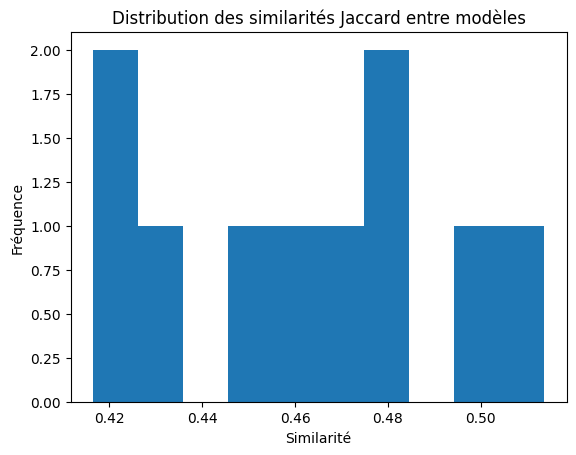

In [72]:
import matplotlib.pyplot as plt

plt.hist(similarities, bins=10)
plt.title("Distribution des similarités Jaccard entre modèles")
plt.xlabel("Similarité")
plt.ylabel("Fréquence")
plt.show()

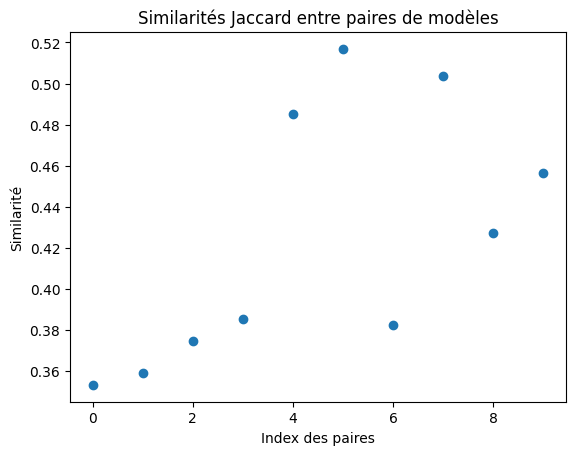

In [71]:
plt.scatter(range(len(similarities)), similarities)

plt.title("Similarités Jaccard entre paires de modèles")
plt.xlabel("Index des paires")
plt.ylabel("Similarité")

plt.show()

Topic 0 : nbr, week, pompier, autre, heure, eau, rue, orage, nouveau, inondation
Topic 1 : nbr, week, mort, région, ville, autre, personne, sud, inondation, incendie
Topic 2 : nbr, année, pays, autre, week, nbr_million, nouveau, rapport, jour, premier
Topic 3 : nbr, animal, autre, certain, journaliste, drone, nouveau, cas, week, région
Topic 4 : nbr, nouveau, autre, projet, certain, premier, année, grand, commun, eau
Topic 5 : eau, nbr, autre, année, agriculteur, certain, petit, arbre, culture, nouveau
Topic 6 : nbr, autre, antarctique, zone, glacier, eau, région, scientifique, étude, année
Topic 7 : eau, nbr, autre, certain, année, nouveau, grand, week, commun, maison


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/81071035.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="Stabilité", y="Topic", palette=colors, edgecolor=".2")


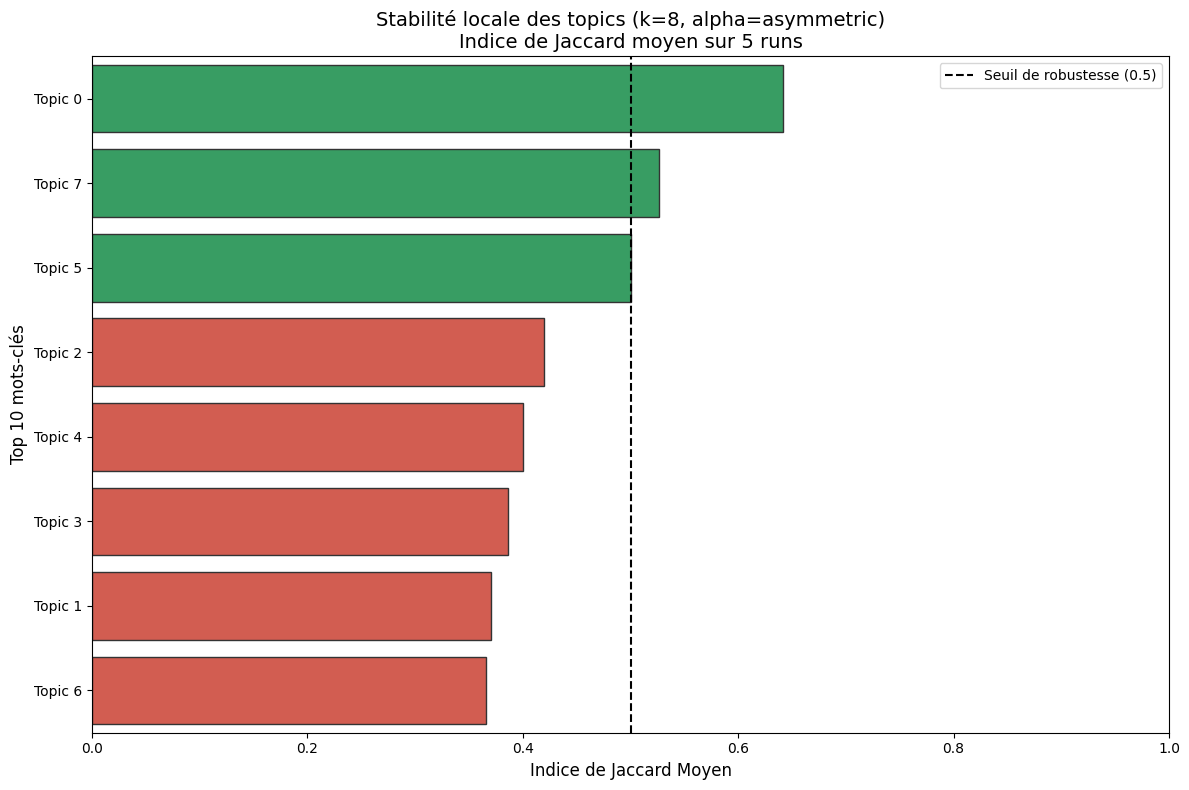

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul de la stabilité par topic (en prenant le premier modèle comme référence)
reference_topics = topic_sets[0]
stability_per_topic = []

# On récupère le modèle de référence pour extraire proprement les mots-clés
# Impression des mots
for idx in range(len(reference_topics)):
    words_list = [w for w, _ in lda_model.show_topic(idx, topn=10)]
    print(f"Topic {idx} : {', '.join(words_list)}")

# Construction des données pour le plot
for idx, t_ref in enumerate(reference_topics):
    scores_across_runs = []
    
    for other_run in topic_sets[1:]:
        max_sim = max(jaccard_similarity(t_ref, t_other) for t_other in other_run)
        scores_across_runs.append(max_sim)
    
    avg_sim = np.mean(scores_across_runs)
    
    # Label simplifié
    label = f"Topic {idx}"
    
    stability_per_topic.append({"Topic": label, "Stabilité": avg_sim})

# 2. Création du DataFrame et tri
df_plot = pd.DataFrame(stability_per_topic).sort_values("Stabilité", ascending=False)

# 3. Génération du Barplot
plt.figure(figsize=(12, 8))
# Couleur dynamique : vert si stable (>0.5), rouge sinon
colors = ["#27ae60" if x > 0.5 else "#e74c3c" for x in df_plot["Stabilité"]]

sns.barplot(data=df_plot, x="Stabilité", y="Topic", palette=colors, edgecolor=".2")

plt.axvline(x=0.5, color='black', linestyle='--', label='Seuil de robustesse (0.5)')
plt.title(f"Stabilité locale des topics (k=8, alpha={alpha_test})\nIndice de Jaccard moyen sur 5 runs", fontsize=14)
plt.xlabel("Indice de Jaccard Moyen", fontsize=12)
plt.ylabel("Top 10 mots-clés", fontsize=12)
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


Fixer le seuil à 0.5 est tout à fait acceptable et même courant en analyse de données textuelles réelles (souvent "bruitées").
Voici pourquoi le choix de 0.5 est pertinent et ce qu'il implique :
1. La signification mathématique (50%)
Un indice de Jaccard de 0.5 signifie que pour 10 mots-clés extraits, 6 ou 7 mots sont communs entre deux versions du même topic.
C'est le point de bascule : il y a plus de mots partagés que de mots différents (

).
Sémantiquement, cela garantit que le "cœur" du sujet reste le même, même si les mots secondaires varient.

## modifications apportes au model final. 

 pour garder le modèle le plus interpretable possible , nous avons decider  de suprimer quelques mots très fréquants tels que nbr et autre qui apparaissent dans toutes les thématiques, et  ainsi que ceux qui apparaissent dans plus de 5O% du corpus et dans moins de 5 documents et  c'est ce dictionaire qui est utilisé pour les modèles suivants. 

In [75]:
# Avant le filtre — sauvegarder le vocabulaire initial
vocab_avant = set(dictionary.token2id.keys())

# ─── Filtrage ─────────────────────────────────────────────────────────────────
new_dic = dictionary
new_dic.filter_extremes(no_below=5, no_above=0.5)

mots_a_supprimer = ["nbr", "autre", "nouveau", "week", "eau"]
stop_ids = [
    new_dic.token2id[word]
    for word in mots_a_supprimer
    if word in new_dic.token2id
]
new_dic.filter_tokens(bad_ids=stop_ids)
new_dic.compactify()
new_corpus = [new_dic.doc2bow(text) for text in texts_filtered]

# ─── Mots supprimés ───────────────────────────────────────────────────────────
vocab_apres = set(new_dic.token2id.keys())

supprimes = vocab_avant - vocab_apres

print(f"Vocabulaire avant : {len(vocab_avant):,} mots")
print(f"Vocabulaire après : {len(vocab_apres):,} mots")
print(f"Mots supprimés    : {len(supprimes):,}\n")

# Mots supprimés par filter_extremes (trop rares ou trop fréquents)
supprimes_extremes = supprimes - set(mots_a_supprimer)
print(f"─── Supprimés par filter_extremes ({len(supprimes_extremes):,} mots) ───")
print(sorted(supprimes_extremes)[:50])  # afficher les 50 premiers

# Mots supprimés manuellement
supprimes_manuels = set(mots_a_supprimer) & supprimes
print(f"\n─── Supprimés manuellement ({len(supprimes_manuels)}) ───")
print(supprimes_manuels)

# Mots manuels absents du dictionnaire (déjà supprimés par filter_extremes)
absents = set(mots_a_supprimer) - supprimes
if absents:
    print(f"\n⚠ Déjà absents avant suppression manuelle : {absents}")

Vocabulaire avant : 14,941 mots
Vocabulaire après : 14,941 mots
Mots supprimés    : 0

─── Supprimés par filter_extremes (0 mots) ───
[]

─── Supprimés manuellement (0) ───
set()

⚠ Déjà absents avant suppression manuelle : {'autre', 'week', 'nbr', 'nouveau', 'eau'}


### seconde analyse après nettoyage du corpus. 

In [76]:
import numpy as np
from itertools import combinations
from gensim.models.ldamulticore import LdaMulticore

# seeds pour test de robustesse
seeds = [0, 21, 42, 84, 123]

def get_top_words(model, topn=50):
    topics = []
    for t in range(model.num_topics):
        words = [w for w, _ in model.show_topic(t, topn=topn)]
        topics.append(set(words))
    return topics

def jaccard_similarity(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

# récupérer les meilleurs hyperparamètres

topic_sets = []

for seed in seeds:

    lda_model = LdaMulticore(
        corpus=new_corpus,
        num_topics=8,
        id2word=new_dic,
        alpha="asymmetric",
        passes=15,
        iterations=50,
        workers=8,
        random_state=seed
    )

    topic_sets.append(get_top_words(lda_model))

similarities = []

for (i, topics1), (j, topics2) in combinations(enumerate(topic_sets), 2):

    topic_sim = []

    for t1 in topics1:
        max_sim = max(jaccard_similarity(t1, t2) for t2 in topics2)
        topic_sim.append(max_sim)

    similarities.append(np.mean(topic_sim))

print("Similarité moyenne Jaccard :", np.mean(similarities))

Similarité moyenne Jaccard : 0.4865925463108686


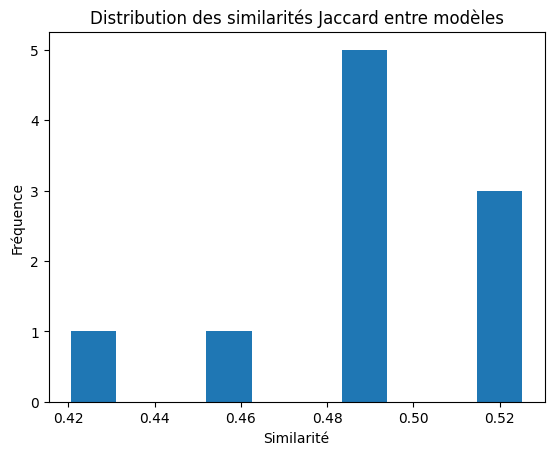

In [50]:
import matplotlib.pyplot as plt

plt.hist(similarities, bins=10)
plt.title("Distribution des similarités Jaccard entre modèles")
plt.xlabel("Similarité")
plt.ylabel("Fréquence")
plt.show()

Topic 0 : mort, région, ville, inondation, personne, sud, nord, etat, pluie, maison
Topic 1 : certain, projet, cas, commun, premier, bruxelle, train, dernier, travail, côté
Topic 2 : ville, mort, personne, pays, gouvernement, grand, premier, capital, certain, président
Topic 3 : personne, femme, nbr_million, pays, cas, mort, enfant, président, année, premier
Topic 4 : année, température, jour, région, situation, certain, agriculteur, petit, normal, chaleur
Topic 5 : région, vol, heure, accident, mort, mission, zone, appareil, avion, premier
Topic 6 : année, rapport, pays, climat, scientifique, nbr_million, certain, prix, étude, grand
Topic 7 : pompier, incendie, commun, rue, région, maison, heure, situation, ville, inondation


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/81071035.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="Stabilité", y="Topic", palette=colors, edgecolor=".2")


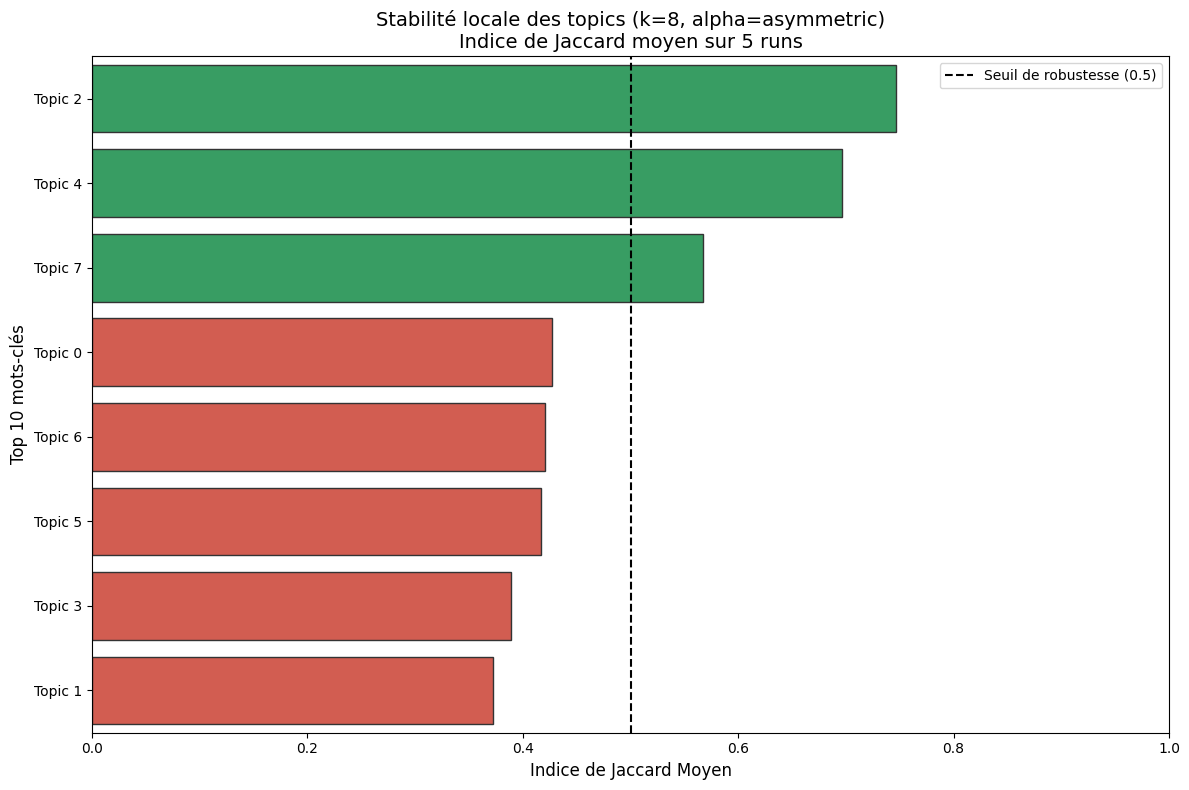

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul de la stabilité par topic (en prenant le premier modèle comme référence)
reference_topics = topic_sets[0]
stability_per_topic = []

# On récupère le modèle de référence pour extraire proprement les mots-clés
# Impression des mots
for idx in range(len(reference_topics)):
    words_list = [w for w, _ in lda_model.show_topic(idx, topn=10)]
    print(f"Topic {idx} : {', '.join(words_list)}")

# Construction des données pour le plot
for idx, t_ref in enumerate(reference_topics):
    scores_across_runs = []
    
    for other_run in topic_sets[1:]:
        max_sim = max(jaccard_similarity(t_ref, t_other) for t_other in other_run)
        scores_across_runs.append(max_sim)
    
    avg_sim = np.mean(scores_across_runs)
    
    # Label simplifié
    label = f"Topic {idx}"
    
    stability_per_topic.append({"Topic": label, "Stabilité": avg_sim})

# 2. Création du DataFrame et tri
df_plot = pd.DataFrame(stability_per_topic).sort_values("Stabilité", ascending=False)

# 3. Génération du Barplot
plt.figure(figsize=(12, 8))
# Couleur dynamique : vert si stable (>0.5), rouge sinon
colors = ["#27ae60" if x > 0.5 else "#e74c3c" for x in df_plot["Stabilité"]]

sns.barplot(data=df_plot, x="Stabilité", y="Topic", palette=colors, edgecolor=".2")

plt.axvline(x=0.5, color='black', linestyle='--', label='Seuil de robustesse (0.5)')
plt.title(f"Stabilité locale des topics (k=8, alpha={alpha_test})\nIndice de Jaccard moyen sur 5 runs", fontsize=14)
plt.xlabel("Indice de Jaccard Moyen", fontsize=12)
plt.ylabel("Top 10 mots-clés", fontsize=12)
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


### construction du best model LDA 

 ### **Interpretation graphique**

Cette interprétation est tirée de :
**Sievert, C., & Shirley, K. E. (2014).** *LDAvis: A method for visualizing and interpreting topics.*  
In Proceedings of the workshop on interactive language learning, visualization, and interfaces (pp. 63-70).

#### Panel de Gauche  :  Carte de Distance Inter-Topics (Intertopic Distance Map)
- **chaque cercle(Bulles)** : représente un topic individuel.  le centre du cerle est calculer comme étant la distance entre deux topics. Et on utilise le multidimensional scaling pour projecter la distance inter-topic en deux dimensions(**2D**)
- **taille de cerles** : la taille relative d'un cercle indique la fréquence ou la prévalence relative de ce topic dans l'ensemble du corpus de documents. un cerle plus grand signifie un topic plus discuté. 

- **Distance entre les cercles** : la distance entre les centres des cercles repésente la similarité sémentique  entre les topics. 
   - les topics proches les uns des autres partagent des mots similaires ou apparaissent dans des contextes similaires. 
   - les topics éloignés sont distincts et traitent de sujets différents. 

- **Positionnement** : un bon modèle aura des bulles de taille raisonnable, bien séparées et dispersées sur le graphique, plutôt que des petites bulles regroupées et se chevauchant dans un seul quadrent.  de façon générale, le chevauchement  indique souvent  que les topics ne sont pas suffisamment distincts.

#### Panel de Droite : Termes les plus pertinets pour un topic Sélectionné. 

Lorsque nous  cliquons  sur un cercle (topic) dans le panel de gauche, le panel de droite se met à jour pour afficher les termes les plus pertinents pour ce topic spécifique.

-  **Les Barres** : Affichent les mots les plus importants du topic sélectionné. Par défaut, les 30 termes les plus pertinents sont affichés. La pertinence (**Relevance**) de ses  termes est calculé comme suit:
$$
r(w, k \mid \lambda) = 
\lambda \, \log({\phi}_{kw}) + 
(1 - \lambda) \, \log\left(\frac{{\phi}_{kw}}{p_w}\right)
$$
avec:   
      - $r(w, k \mid \lambda)$ : score de **pertinence** du mot $w$ pour le topic $k$        
      - $\lambda \in [0, 1]$ : **paramètre d'équilibre** entre fréquence et spécificité  
      - $\phi_{kw}$ : **probabilité du mot $w$** dans le **topic $k$**  
  (autrement dit, à quel point ce mot est représentatif du thème)        
      - $p_w$ : **probabilité globale du mot $w$** dans **tout le corpus**  
  (à quelle fréquence il apparaît dans l'ensemble des documents)
   
-  **Barre Bleue (ou Grise)** : Représente la fréquence globale de ce terme dans l'ensemble du corpus de documents (prévalence marginale).
-  **Barre Rouge** : Représente la fréquence pondérée ou la pertinence du terme dans le topic sélectionné.
-  **Curseur de Pertinence ( $ \lambda $)**  : C'est un outil essentiel pour l'interprétation.

   - En ajustant le curseur $\lambda$ (lambda) entre 0 et 1, nous  modifions  la métrique de pertinence. Lambda determine le poids donné à la probabilité du terme w sous le topic k par rapport  à son lift 
   
      - $ \lambda = 1 $ (valeur élevée) met l'accent sur les mots les plus fréquents dans le topic, sans nécessairement être exclusifs. Les termes sont juste rangés selon $\phi_{kw}$

      - $\lambda = 0 $ (valeur faible) met l'accent sur les mots les plus distinctifs ou exclusifs au topic (ceux qui ont un "lift" élevé, c'est-à-dire qui apparaissent beaucoup plus souvent dans ce topic que dans le corpus général). Le **Lift** se défini comme étant le rapport entre la probabilité d'un terme dans un sujet et sa probabilité marginale à travers le corpus. 
      
      - Expérimenter avec $\lambda$ (souvent autour de 0.6 selon certaines études) vous aide à trouver un équilibre pour identifier des termes cohérents qui définissent clairement le sujet du topic. 

La séléction d'un terme à droite , revèle sa distribution conditionnelle  à travers tous les topics(à gauche). les terms à droites sont classés du plus important au moins important.  


## Test des valeurs LDA pour un $k=7$

In [52]:
from gensim.models.ldamulticore import LdaMulticore
workers = os.cpu_count() - 1  # utilise presque tous les cœurs

best_lda_model_7 = LdaMulticore(
    corpus=new_corpus,
    id2word=new_dic,
    num_topics=8,
    passes=200,
    iterations=1000,
    chunksize=4000,
    alpha='symmetric',
    eta='auto',
    random_state=123,
    workers=workers,
    eval_every=None
)

In [53]:
lda_display_7 = gensimvis.prepare(best_lda_model_7, new_corpus, new_dic, sort_topics=False)

# Affichage du model LDA 
pyLDAvis.display(lda_display_7)

In [54]:
!pip install openai

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.2 MB/s  0:00:01 eta 0:00:010m
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [openai]2m3/4 [openai]


In [ ]:
from openai import OpenAI

#client = OpenAI(api_key= "mettre votre propre clé")

def get_representative_docs(model, corpus, texts_raw, topic_id, n_docs=3):
    """Récupère les n documents les plus représentatifs d'un topic."""
    doc_scores = []
    for i, doc in enumerate(corpus):
        topic_dist = dict(model.get_document_topics(doc))
        score = topic_dist.get(topic_id, 0)
        doc_scores.append((i, score))
    
    top_docs = sorted(doc_scores, key=lambda x: x[1], reverse=True)[:n_docs]
    return [texts_raw[i] for i, _ in top_docs]


def label_topic(model, topic_id, corpus, texts_raw, n_words=25, n_docs=3):
    """Génère un label pour un topic via l'API OpenAI."""
    
    # Top N mots
    words = [w for w, _ in model.show_topic(topic_id, topn=n_words)]
    words_str = ", ".join(words)
    
    # Documents représentatifs
    docs = get_representative_docs(model, corpus, texts_raw, topic_id, n_docs)
    docs_str = "\n\n".join([f"Document {i+1} : {d[:300]}..." 
                             for i, d in enumerate(docs)])
    
    # Prompt
    prompt = f"""Tu es un expert en analyse thématique académique.

Voici les mots-clés d'un topic LDA : {words_str}

Voici quelques documents représentatifs :
{docs_str}

Donne :
- un label thématique court
- en français
- académique
- maximum 6 mots
- sans guillemets"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=50
    )
    
    return response.choices[0].message.content.strip()


# ─── Labellisation de tous les topics ────────────────────────────────────────
labels = {}

for topic_id in range(best_lda_model_7.num_topics):
    label = label_topic(
        model=best_lda_model_7,
        topic_id=topic_id,
        corpus=new_corpus,
        texts_raw=texts_filtered,  # vos textes bruts
        n_words=25,
        n_docs=3
    )
    labels[topic_id] = label
    print(f"Topic {topic_id} → {label}")

# ─── Affichage récapitulatif ──────────────────────────────────────────────────
print("\n─── Labels finaux ───")
for topic_id, label in labels.items():
    words = [w for w, _ in best_lda_model_7.show_topic(topic_id, topn=10)]
    print(f"Topic {topic_id:2d} | {label:<40} | {', '.join(words[:5])}")

Topic 0 → Catastrophes naturelles et impacts humains
Topic 1 → Gestion des inondations urbaines et projets
Topic 2 → Politique, médias et liberté d'expression
Topic 3 → Santé publique et impacts environnementaux
Topic 4 → Changements climatiques et agriculture durable
Topic 5 → Catastrophes naturelles et pertes humaines
Topic 6 → Changements climatiques et impacts forestiers
Topic 7 → Interventions des pompiers en intempéries

─── Labels finaux ───
Topic  0 | Catastrophes naturelles et impacts humains | inondation, mort, personne, ville, etat
Topic  1 | Gestion des inondations urbaines et projets | commun, projet, certain, cas, ville
Topic  2 | Politique, médias et liberté d'expression | pays, politique, gouvernement, président, grand
Topic  3 | Santé publique et impacts environnementaux | cas, personne, hôpital, enfant, maladie
Topic  4 | Changements climatiques et agriculture durable | année, température, jour, agriculteur, chaleur
Topic  5 | Catastrophes naturelles et pertes humaine

In [ ]:
pyLDAvis.save_html(lda_display, 'lda_interactif.html')

In [ ]:
import numpy as np

lambda_val = 0.6
num_terms = 25
all_topics = {}

# Calcul de la fréquence globale des mots
term_freq = {dictionary[id]: freq for id, freq in dictionary.cfs.items()}
total_freq = sum(term_freq.values())

for i in range(best_lda_model_7.num_topics):
    # Récupérer les log(probabilité du mot dans le topic)
    topic_terms = best_lda_model_7.get_topic_terms(i, topn=len(dictionary))
    
    data = []
    for term_id, prob in topic_terms:
        word = dictionary[term_id]
        p_wt = prob
        p_w = term_freq[word] / total_freq
        relevance = lambda_val * np.log(p_wt) + (1 - lambda_val) * np.log(p_wt / p_w)
        data.append((word, relevance))
    
    # Trie  des mots les plus "relevants"
    top_words = sorted(data, key=lambda x: x[1], reverse=True)[:num_terms]
    all_topics[f"Topic {i+1}"] = [w for w, _ in top_words]

# Affichage
for topic, words in all_topics.items():
    print(f"{topic}: {', '.join(words)}")


Topic 1: cyclone, etat, inondation, tempête, typhon, mort, personne, ouragan, ville, sud, tempêt, tempête_tropical, autorité, philippine, haïti, archipel, nord, nbr_million, côte, américain, maison, toucher_terre, cuba, gouverneur, région
Topic 2: commun, projet, traval, travail, cas, chantier, dossier, certain, entreprise, bruxelle, site, propriétaire, wallon, exemple, service, communal, société, mesure, public, niveau, bâtiment, plan, problème, déchet, train
Topic 3: politique, président, gouvernement, guerre, pays, grand, américain, premier, jeune, groupe, français, journaliste, opposition, manifestation, violence, film, militaire, conflit, affaire, image, histoire, candidat, crise, enfant, réfugié
Topic 4: hôpital, maladie, médecin, patient, enfant, santé, cas, décès, virus, animal, ozone, épidémie, personne, traitement, femme, médicament, médical, malade, covid, symptôme, infirmier, surmortalité, sanitaire, soin, chien
Topic 5: année, température, agriculteur, chaleur, jour, cultu

In [66]:
# Extraire les 2 docs représentatifs par topic
for i in range(best_lda_model_7.num_topics):
    docs = get_representative_docs(
               best_lda_model_7, new_corpus, texts_filtered, i, n_docs=2)
    print(f"\n=== Topic {i} : {labels_existants[i]} ===")
    for idx, doc in docs:
        print(f"--- Doc {idx} ---")
        print(doc[:300])
        print()


=== Topic 0 : Catastrophes naturelles et impacts humains ===
--- Doc 3281 ---
['trente_minute', 'terreur', 'alice', 'clement', 'responsable', 'unicef', 'place', 'décrire', 'passage', 'vanuatu', 'pam', 'cyclone_catégorie', 'nbr', 'premier', 'information', 'pouvoir_être', 'pire_histoire', 'pacifique', 'vivien', 'directrice', 'exécutif', 'unicef', 'nouveau_zélande', 'destruction', 'impossible', 'week', 'vanuatu', 'cyclone', 'archipel', 'nuit', 'week', 'week', 'nbr', 'victime', 'nombre', 'important', 'victime', 'ampleur', 'bilan', 'déclarer_afp', 'sun', 'gudnitz', 'chef_bureau', 'nation_unir_coordination_affaire', 'pacifique', 'destruction', 'décombre', 'rue', 'inondation', 'gudnitz', 'information', 'nbr_personne_péri', 'seul', 'province', 'vanuatu', 'matin', 'spectacle', 'dévastation', 'total', 'skirrow', 'organisation_humanitaire', 'capital', 'vanuatu', 'port_vila', 'maison_détruire', 'arbre', 'rue', 'bloquée', 'gens', 'rue', 'recherche_secour', 'communication', 'interrompre', 'complet'

In [ ]:
topic_distributions = [best_lda_model_7.get_document_topics(doc, minimum_probability=0) for doc in corpus]
dominant_topics = [max(doc, key=lambda x: x[1])[0] for doc in topic_distributions]
df_select_trie2['dominant_topic'] = dominant_topics

In [ ]:
"""topics_per_year = df_select_trie2.groupby(['year', 'dominant_topic']).size().reset_index(name='n')
print(topics_per_year)"""

In [ ]:
"""topics_per_year = (
    df_select_trie2
    .groupby(['year', 'dominant_topic'])
    .size()
    .reset_index(name='n')
)

# S'assurer que les colonnes sont de type string/catégorique
topics_per_year['dominant_topic'] = topics_per_year['dominant_topic'].astype(str)
topics_per_year['year'] = topics_per_year['year'].astype(str)

# Tracer le graphique
fig = px.bar(
    topics_per_year,
    x='year',
    y='n',
    color='dominant_topic',
    barmode='group',  # barres côte à côte
    title="Nombre d'articles par topic et par année",
    labels={'n': "Nombre d'articles", 'dominant_topic': "Topic", 'year': "Année"}
)

#  Amélioration lisibilité
fig.update_layout(
    legend_title_text='Topic',
    xaxis_tickangle=-45
)
fig.write_image("evol_topic_year.png", scale=2, width=850, height=450)
fig.show()"""

# Implementation du DTM (dynamic Topic models.)

## Création du Time slices. 

In [78]:
df_select_trie2["annee_index"] = df_select_trie2["annee"] - df_select_trie2["annee"].min()



/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/168701739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2["annee_index"] = df_select_trie2["annee"] - df_select_trie2["annee"].min()


In [ ]:
#print(df_select_trie2["annee_index"])

## model en lui même. 


 ici, nous découpons notre corpus en période, chaque periodes   on observe le score  de jensen-shannon pour trouver le meilleur time split.

In [ ]:
#pip install tomotopy

In [79]:
from collections import Counter
all_words = [word for text in texts_filtered for word in text]
most_freq = Counter(all_words).most_common(100)
print(most_freq) 
print(len(most_freq))

[('nbr', 35477), ('week', 8043), ('autre', 5093), ('eau', 4470), ('nouveau', 3483), ('région', 3325), ('ville', 3156), ('année', 2892), ('personne', 2803), ('mort', 2704), ('certain', 2654), ('inondation', 2530), ('pays', 2194), ('premier', 2165), ('heure', 2017), ('nombreux', 1944), ('dernier', 1927), ('sud', 1895), ('grand', 1767), ('pompier', 1760), ('nord', 1751), ('jour', 1726), ('situation', 1714), ('zone', 1687), ('maison', 1675), ('incendie', 1654), ('petit', 1566), ('température', 1558), ('centre', 1520), ('raison', 1490), ('important', 1477), ('cas', 1462), ('nbr_million', 1441), ('seul', 1386), ('orage', 1355), ('commun', 1310), ('niveau', 1306), ('etat', 1301), ('pouvoir_être', 1299), ('partie', 1266), ('autorité', 1220), ('rapport', 1214), ('côté', 1199), ('gouvernement', 1190), ('pluie', 1139), ('capital', 1118), ('américain', 1103), ('rue', 1102), ('effet', 1075), ('responsable', 1065), ('population', 1063), ('afp', 1062), ('terre', 1045), ('local', 1044), ('cours', 1041

In [80]:
# nettoyage du corpus. 

# Nettoyage des textes (enlever les mots interdits)
texts_cleaned = [
    [word for word in doc if word not in mots_a_supprimer]
    for doc in texts_filtered
]

## test pour trouver le meilleure rm_top 

In [ ]:
# On fixe un nombre de périodes raisonnable (ex: 8)
n_test = 8
df_select_trie2["periode_test"] = pd.qcut(df_select_trie2["annee_index"].rank(method="first"), q=n_test, labels=False)

test_rm_values = [10, 20, 30, 40, 50, 60, 80, 100]
scores_coh = []

for r in test_rm_values:
    _, score = entrainer_dtm(texts_cleaned, df_select_trie2["periode_test"], k=5, n_periodes=n_test, rm_top=r)
    scores_coh.append(score)
    print(f"Test rm_top={r} | Cohérence U_mass={score:.4f}")

# Visualisation pour choisir
plt.plot(test_rm_values, scores_coh, marker='o')
plt.title("Choix du rm_top optimal (Cohérence U_mass)")
plt.xlabel("Nombre de mots supprimés (rm_top)")
plt.ylabel("Score U_mass (plus proche de 0 est mieux)")
plt.show()

In [ ]:
"""# Afficher le score pour le découpage en 6 périodes
print(f"Cohérence pour 6 périodes : {results[6]['coherence']:.4f}")

# Afficher le score pour le découpage en 10 périodes
print(f"Cohérence pour 10 périodes : {results[10]['coherence']:.4f}")"""

In [ ]:
df_select_trie2.loc[:, "periode"] = pd.qcut(
    df_select_trie2["annee_index"].rank(method="first"), # methode first garantie que chaque période à exactement le même nombre de documents 
    q=4, 
    labels=False
).astype(int) # On force l'entier pour tomotopy

In [ ]:
# Compter le nombre de documents par période
stats_periodes = df_select_trie2['periode'].value_counts().sort_index()

# Voir les années min et max pour chaque période
dates_limites = df_select_trie2.groupby('periode')['annee_index'].agg(['min', 'max', 'count'])
print(dates_limites)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_select_trie2['annee_reelle'] = df_select_trie2['annee_index'] + 2008 
plt.figure(figsize=(12, 6))

# On utilise "dodge" ou "stack" mais avec des contours plus nets
sns.histplot(
    data=df_select_trie2, 
    x="annee_reelle", 
    hue="periode", 
    multiple="stack", # Garder stack pour voir le volume total par an
    palette="viridis",
    discrete=True,    # Important pour des années (valeurs entières)
    edgecolor="white",
    linewidth=0.5
)

# Configuration de l'axe X pour afficher chaque année
plt.xticks(range(2008, 2023)) 

plt.title("Répartition des 8 périodes RTBF (2008-2022)", fontsize=14, pad=20)
plt.xlabel("Année de publication", fontsize=12)
plt.ylabel("Nombre d'articles", fontsize=12)

# Amélioration de la légende
plt.legend(title="Périodes du DTM", 
           labels=[f"P4", f"P3", f"P2", f"P1 (Début)"],
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


In [82]:
import tomotopy as tp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
# =========================================================
# 1. Construire un modèle DTM
# =========================================================

def entrainer_dtm(texts, timepoints, k=5, n_periodes=10 , rm_top=30):

    dtm = tp.DTModel(
        k=k,
        t=n_periodes,
        min_cf=5,
        min_df=5,
        rm_top=rm_top, #suprime les n mots les plus fréquents du corpus. 
        seed=123
    )

    for tokens, t in zip(texts, timepoints):
        dtm.add_doc(tokens, timepoint=int(t))

    dtm.burn_in = 200
    dtm.train(1500)
    # calcul du score de cohérence U_mass 
    coh = tp.coherence.Coherence(dtm,coherence='u_mass')
    coherence_score = coh.get_score()
    print("LL per word:", dtm.ll_per_word)

    return dtm, coherence_score


# =========================================================
# 2. Extraire distributions de mots des topics
# =========================================================

def get_topic_distribution(dtm, topic_id, timepoint, vocab_size=50):

    words_probs = dtm.get_topic_words(
        topic_id,
        top_n=vocab_size,
        timepoint=timepoint
    )

    probs = np.array([p for _, p in words_probs])

    probs = probs / probs.sum()

    return probs


# =========================================================
# 3. Mesurer variation entre périodes
# =========================================================

def mesurer_variations_js(dtm, k, n_periodes):

    js_variations = []
    evolution_poids = []

    for topic_id in range(k):

        js_topic = []

        for t in range(n_periodes - 1):

            dist1 = get_topic_distribution(dtm, topic_id, t)
            dist2 = get_topic_distribution(dtm, topic_id, t+1)

            js = jensenshannon(dist1, dist2)

            js_topic.append(js)

        js_variations.append(js_topic)

        poids_par_periode = []

        for t in range(n_periodes):

            docs = [doc for doc in dtm.docs if doc.timepoint == t]

            if docs:
                poids = np.mean([doc.get_topic_dist()[topic_id] for doc in docs])
            else:
                poids = 0

            poids_par_periode.append(poids)

        evolution_poids.append(poids_par_periode)

    return js_variations, evolution_poids


# =========================================================
# 4. Tester différentes granularités temporelles
# =========================================================

def analyser_granularite_temporelle(
    df,
    texts,
    colonne_date,
    k=5,
    time_splits=[3,4,5,6,8,10,12],
    rm_top=10
):

    results = {}

    for n_periodes in time_splits:

        print(f"\n=== Test avec {n_periodes} périodes ===")

        df["periode"] = pd.qcut(
            df[colonne_date].rank(method="first"),
            q=n_periodes,
            labels=False
        )

        dtm, score_coh = entrainer_dtm(
            texts,
            df["periode"],
            k=k,
            n_periodes=n_periodes,
            rm_top=rm_top
        )

        js_variations, evolution_poids = mesurer_variations_js(
            dtm,
            k,
            n_periodes
        )

        js_moyen = np.mean([np.mean(v) for v in js_variations])

        results[n_periodes] = {
            "js_variations": js_variations,
            "evolution_poids": evolution_poids,
            "js_moyen": js_moyen,
            "coherence": score_coh
        }

        print("Variation moyenne JS:", js_moyen)
        print(f"Cohérence U_mass: {score_coh:.4f}")
    return results


# =========================================================
# 5. Visualisation des résultats
# =========================================================

def visualiser_variations(results):

    splits = list(results.keys())

    js_scores = [results[s]["js_moyen"] for s in splits]

    plt.figure(figsize=(8,5))

    plt.plot(splits, js_scores, marker="o")

    plt.title("Variation moyenne des topics selon la granularité temporelle")
    plt.xlabel("Nombre de périodes")
    plt.ylabel("Jensen-Shannon divergence moyenne")

    plt.grid(True)

    plt.show()


# =========================================================
# 6. Heatmap évolution des topics
# =========================================================

def visualiser_evolution_topics(results, split):

    evo = results[split]["evolution_poids"]

    plt.figure(figsize=(10,6))

    sns.heatmap(
        evo,
        cmap="viridis",
        annot=False
    )

    plt.xlabel("Périodes")
    plt.ylabel("Topics")

    plt.title(f"Evolution des topics (split={split})")

    plt.show()


# =========================================================
# 7. Utilisation
# =========================================================

In [81]:
import tomotopy as tp

dtm = tp.DTModel(
    k=5,                # nombre de topics
    t=df_select_trie2["periode"].nunique(),  # nombre de périodes
    min_cf=5,
    min_df=5,
    rm_top=10, 
    seed=123
)

for tokens, time in zip(texts_cleaned, df_select_trie2["periode"]):
    dtm.add_doc(tokens, timepoint=time)

dtm.burn_in = 100
dtm.train(2000)

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type _VocabDict has no __module__ attribute


KeyError: 'periode'

In [ ]:
summary = []

for t in range(dtm.num_timepoints):
    row = {"Période": t}
    for k in range(dtm.k):
        words = [w for w, p in dtm.get_topic_words(k, timepoint=t, top_n=25)]
        row[f"Sujet {k}"] = ", ".join(words)
    summary.append(row)

df_all_topic = pd.DataFrame(summary).set_index("Période")
#  affichage propre dans le  notebook :
display(df_all_topic) 

In [ ]:
import matplotlib.pyplot as plt

topic = 0
proportions = []

for t in range(dtm.num_timepoints):
    vals = [doc.get_topic_dist()[topic] 
            for doc in dtm.docs if doc.timepoint == t]
    proportions.append(sum(vals)/len(vals))

plt.plot(proportions)
plt.xlabel("Time")
plt.ylabel("Topic proportion")
plt.show()

In [ ]:
labels_periodes = []
for p in range(6):
    # On cherche l'année min et max pour chaque groupe (0 à 5)
    d_min = df_select_trie2[df_select_trie2['periode'] == p]['annee_index'].min() + 2008
    d_max = df_select_trie2[df_select_trie2['periode'] == p]['annee_index'].max() + 2008
    labels_periodes.append(f"{int(d_min)}-{int(d_max)}")

In [ ]:
import matplotlib.pyplot as plt
import math

# 1. Configuration de la grille (ex: 3 colonnes)
n_topics = dtm.k
n_cols = 3
n_rows = math.ceil(n_topics / n_cols)

# 2. Création de la figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharey=True)
axes = axes.flatten() # Pour boucler facilement sur la grille

for topic_id in range(n_topics):
    proportions = []
    
    # Votre logique de calcul pour chaque période
    for t in range(dtm.num_timepoints):
        vals = [doc.get_topic_dist()[topic_id] 
                for doc in dtm.docs if doc.timepoint == t]
        
        if len(vals) > 0:
            proportions.append(sum(vals)/len(vals))
        else:
            proportions.append(0)

    # 3. Tracé sur la facette correspondante
        # 3. Tracé sur la facette correspondante
    ax = axes[topic_id]
    ax.plot(proportions, marker='o', linewidth=2, color='steelblue')
    
    # --- MODIFICATION ICI : AJUSTEMENT DES PÉRIODES ---
    ax.set_xticks(range(len(labels_periodes))) # Positionne un tick par période
    ax.set_xticklabels(labels_periodes, rotation=45, ha='right', fontsize=8) 
    
    # Optionnel : Ajout des mots clés dans le titre
    words_start = [w for w, p in dtm.get_topic_words(topic_id, timepoint=0, top_n=7)]
    words_end = [w for w, p in dtm.get_topic_words(topic_id, timepoint=dtm.num_timepoints-1, top_n=7)]
    
    title = (f"Sujet {topic_id}\n"
             f"Début: {', '.join(words_start)}\n"
             f"Fin: {', '.join(words_end)}")
    
    ax.set_title(title, fontsize=9, pad=10)
    ax.set_xlabel("Périodes temporelles") # Plus précis que "Time"
    ax.set_ylabel("Proportion")
    ax.grid(True, alpha=0.3)


# 4. Nettoyage : enlever les graphiques vides si K n'est pas un multiple de 3
for i in range(topic_id + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

def analyse_semantic_drift(dtm, top_n=25):
    drift_data = []

    for k in range(dtm.k):
        for t in range(dtm.num_timepoints - 1):
            # Récupérer les mots à T et T+1
            words_t = set([w for w, p in dtm.get_topic_words(k, timepoint=t, top_n=top_n)])
            words_t_next = set([w for w, p in dtm.get_topic_words(k, timepoint=t+1, top_n=top_n)])
            
            # Calculer les intersections et les nouveaux mots
            communs = words_t.intersection(words_t_next)
            nouveaux = words_t_next - words_t
            disparus = words_t - words_t_next
            
            # Taux de renouvellement (0 = stable, 1 = 100% nouveau)
            turnover = len(nouveaux) / top_n
            
            drift_data.append({
                "Sujet": k,
                "Transition": f"T{t} -> T{t+1}",
                "Taux_Renouvellement": turnover,
                "Mots_Restants": len(communs),
                "Nouveaux_Mots": ", ".join(list(nouveaux)[:15]), # Top 5 des nouveaux
                "Mots_Sortants": ", ".join(list(disparus)[:15])
            })

    return pd.DataFrame(drift_data)

# --- Exécution et Affichage ---
df_drift = analyse_semantic_drift(dtm)

# affiche les moments où le changement est le plus fort (> 20%)
print("--- Alertes de mutations sémantiques (> 25% de changement) ---")
display(df_drift[df_drift['Taux_Renouvellement'] > 0.25])


# Analyse du DTM à 7 topics 


=== Test avec 3 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.387625032648199
Variation moyenne JS: 0.05092110285947769
Cohérence U_mass: -2.3017

=== Test avec 4 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.431937022326988
Variation moyenne JS: 0.0491324238468082
Cohérence U_mass: -2.2542

=== Test avec 5 périodes ===


...

LL per word: -10.448330071457853
Variation moyenne JS: 0.047501244648963
Cohérence U_mass: -1.9625

=== Test avec 12 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.438913028867542
Variation moyenne JS: 0.04407643988191544
Cohérence U_mass: -1.9147

=== Test avec 13 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.424082967505592
Variation moyenne JS: 0.04326635121032715
Cohérence U_mass: -1.9655


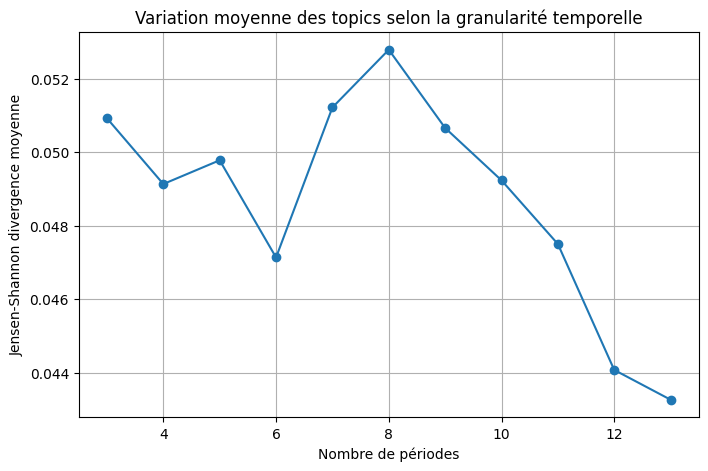

In [83]:
results = analyser_granularite_temporelle(
    df=df_select_trie2,
    texts=texts_cleaned,
    colonne_date="annee_index",
    k=8,
    time_splits=[3,4,5,6,7,8,9,10,11,12,13],
    rm_top=10
)

visualiser_variations(results)

In [ ]:
results_6 = analyser_granularite_temporelle(
    df=df_select_trie2,
    texts=texts_cleaned,
    colonne_date="annee_index",
    k=7,
    time_splits=[7] # On ne teste que le split 10
)

results_3 = analyser_granularite_temporelle(
    df=df_select_trie2,
    texts=texts_cleaned,
    colonne_date="annee_index",
    k=7,
    time_splits=[3] # On ne teste que le split 10
)

In [ ]:
results_8 = analyser_granularite_temporelle(
    df=df_select_trie2,
    texts=texts_cleaned,
    colonne_date="annee_index",
    k=8,
    time_splits=[8] # On ne teste que le split 10
)

# Visualiser la heatmap spécifique pour ce split



=== Test avec 8 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.46983196042981
Variation moyenne JS: 0.052785441539627734
Cohérence U_mass: -2.0601

=== Test avec 10 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.338501873293593
Variation moyenne JS: 0.043711144026770024
Cohérence U_mass: -1.9517


NameError: name 'results_4' is not defined

In [87]:
results_13 = analyser_granularite_temporelle(
    df=df_select_trie2,
    texts=texts_cleaned,
    colonne_date="annee_index",
    k=7,
    time_splits=[13] # On ne teste que le split 10
)


=== Test avec 13 périodes ===


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/47027287.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["periode"] = pd.qcut(
/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


LL per word: -10.310704134625636
Variation moyenne JS: 0.049639575287554916
Cohérence U_mass: -1.9600


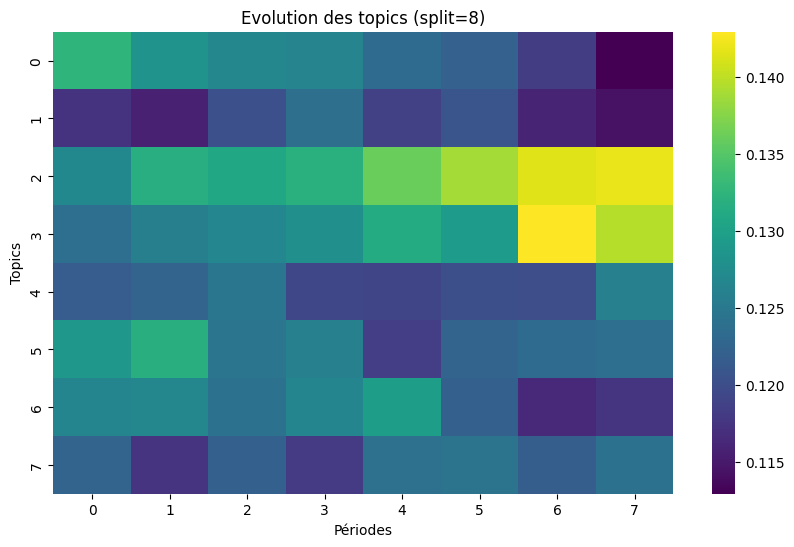

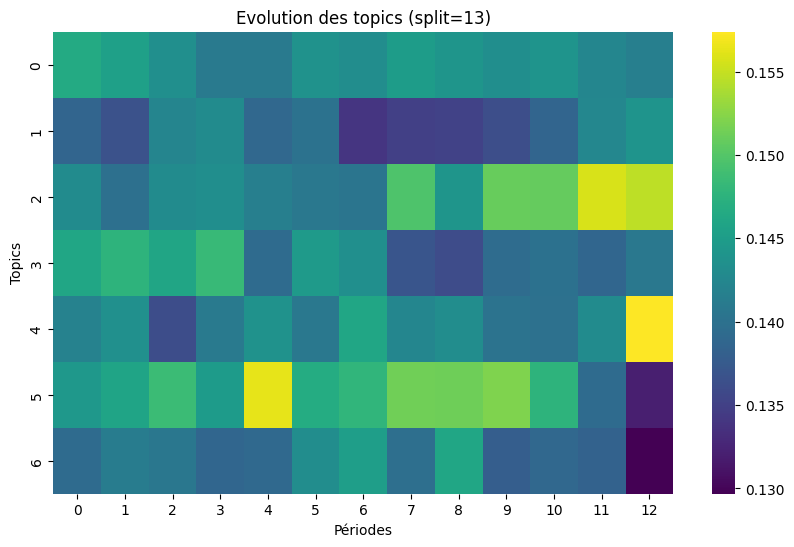

In [88]:
visualiser_evolution_topics(results_8, split=8)
visualiser_evolution_topics(results_13, split=13)

In [89]:
df_select_trie2.loc[:, "periode"] = pd.qcut(
    df_select_trie2["annee_index"].rank(method="first"), # methode first garantie que chaque période à exactement le même nombre de documents 
    q=8, 
    labels=False
).astype(int) # On force l'entier pour tomotopy

In [90]:
# Compter le nombre de documents par période
stats_periodes = df_select_trie2['periode'].value_counts().sort_index()

# Voir les années min et max pour chaque période
dates_limites = df_select_trie2.groupby('periode')['annee_index'].agg(['min', 'max', 'count'])
print(dates_limites)

         min  max  count
periode                 
0          0    2   1120
1          2    5   1120
2          5    7   1119
3          7    8   1120
4          8    9   1120
5          9   10   1119
6         10   11   1120
7         11   13   1120


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_95738/1151173191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2['annee_reelle'] = df_select_trie2['annee_index'] + 2008


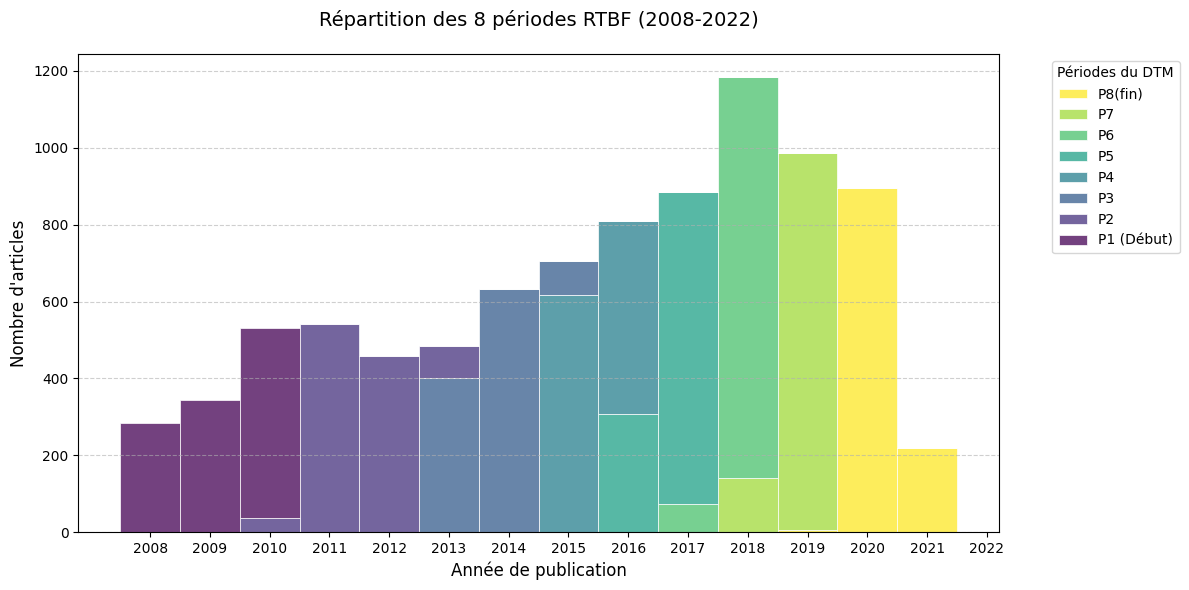

In [100]:
df_select_trie2['annee_reelle'] = df_select_trie2['annee_index'] + 2008 
plt.figure(figsize=(12, 6))

# On utilise "dodge" ou "stack" mais avec des contours plus nets
sns.histplot(
    data=df_select_trie2, 
    x="annee_reelle", 
    hue="periode", 
    multiple="stack", # Garder stack pour voir le volume total par an
    palette="viridis",
    discrete=True,    # Important pour des années (valeurs entières)
    edgecolor="white",
    linewidth=0.5
)

# Configuration de l'axe X pour afficher chaque année
plt.xticks(range(2008, 2023)) 

plt.title("Répartition des 8 périodes RTBF (2008-2022)", fontsize=14, pad=20)
plt.xlabel("Année de publication", fontsize=12)
plt.ylabel("Nombre d'articles", fontsize=12)

# Amélioration de la légende
plt.legend(title="Périodes du DTM", 
           labels=[ f"P8(fin)",f"P7",f"P6",f"P5",f"P4", f"P3", f"P2", f"P1 (Début)"],
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [92]:
import tomotopy as tp
dtm_7 = tp.DTModel(
    k=8,                # nombre de topics
    t=df_select_trie2["periode"].nunique(),  # nombre de périodes
    min_cf=5,
    min_df=5,
    rm_top=10, 
    seed=123
)

for tokens, time in zip(texts_cleaned, df_select_trie2["periode"]):
    dtm_7.add_doc(tokens, timepoint=time)

dtm_7.burn_in = 100
dtm_7.train(2000)

/opt/anaconda3/envs/lda_rtbf/lib/python3.11/site-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


In [ ]:
from openai import OpenAI
import time

#client = OpenAI(api_key="mettre votre propre clé")

# ─── 1. Labellisation par topic ET par période ────────────────────────────────
def label_topic_period(model, texts_raw, topic_id, timepoint, n_words=25, n_docs=2):
    """Génère un label pour un topic à une période donnée."""
    
    # Mots spécifiques à cette période
    words = model.get_topic_words(topic_id, timepoint=timepoint, top_n=n_words)
    words_str = ", ".join([w for w, _ in words])
    
    # Documents représentatifs de cette période
    doc_scores = []
    for i, doc in enumerate(model.docs):
        if doc.timepoint == timepoint:  # seulement les docs de cette période
            topic_dist = doc.get_topic_dist()
            score = topic_dist[topic_id]
            doc_scores.append((i, score))
    
    top_docs = sorted(doc_scores, key=lambda x: x[1], reverse=True)[:n_docs]
    docs_str = "\n\n".join([
        f"Document {i+1} : {' '.join(texts_raw[idx])[:200]}..."
        for i, (idx, _) in enumerate(top_docs)
    ]) if top_docs else "Aucun document disponible pour cette période."

    prompt = f"""Tu es un expert en analyse thématique académique.

Voici les mots-clés d'un topic DTM à la période {timepoint} : {words_str}

Voici quelques documents représentatifs de cette période :
{docs_str}

Donne :
- un label thématique court
- en français
- académique
- maximum 6 mots
- sans guillemets"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=50
    )
    return response.choices[0].message.content.strip()

# ─── 2. Labellisation complète (tous topics × toutes périodes) ────────────────
labels_dtm_dynamic = {}

for topic_id in range(dtm_7.k):
    labels_dtm_dynamic[topic_id] = {}
    for t in range(dtm_7.num_timepoints):
        label = label_topic_period(
            model=dtm_7,
            texts_raw=texts_cleaned,
            topic_id=topic_id,
            timepoint=t,
            n_words=25,
            n_docs=2
        )
        labels_dtm_dynamic[topic_id][t] = label
        print(f"Topic {topic_id:2d} | Période {t:2d} → {label}")
        time.sleep(1)  # éviter le rate limit

# ─── 3. Affichage récapitulatif ───────────────────────────────────────────────
print("\n─── Labels dynamiques DTM ───")
for topic_id in range(dtm_7.k):
    print(f"\nTopic {topic_id}")
    print("-" * 60)
    for t, label in labels_dtm_dynamic[topic_id].items():
        print(f"  Période {t:2d} → {label}")

Topic  0 | Période  0 → Gestion des catastrophes naturelles et urbanisme
Topic  0 | Période  1 → Gestion des catastrophes naturelles locales
Topic  0 | Période  2 → Gestion des catastrophes et évacuations
Topic  0 | Période  3 → Gestion des risques environnementaux et urbains
Topic  0 | Période  4 → Incendies et impacts socio-économiques
Topic  0 | Période  5 → Gestion des catastrophes et impacts climatiques
Topic  0 | Période  6 → Changements climatiques et impacts environnementaux
Topic  0 | Période  7 → Crise socio-économique et environnementale actuelle
Topic  1 | Période  0 → Gestion des crises humanitaires régionales
Topic  1 | Période  1 → Gestion des crises et développement territorial
Topic  1 | Période  2 → Gestion des crises et ressources locales
Topic  1 | Période  3 → Dynamique sociale et territoriale américaine
Topic  1 | Période  4 → Circulation et gestion des infrastructures urbaines
Topic  1 | Période  5 → Gestion des crises environnementales et humaines
Topic  1 | Pér

In [96]:
summary = []
pd.set_option('display.max_colwidth', None)

# Optional: if you have many rows, display all of them
pd.set_option('display.max_rows', None)


for t in range(dtm_7.num_timepoints):
    row = {"Période": t}
    for k in range(dtm_7.k):
        words = [w for w, p in dtm_7.get_topic_words(k, timepoint=t, top_n=25)]
        row[f"Sujet {k}"] = ", ".join(words)
    summary.append(row)

df_all_topic = pd.DataFrame(summary).set_index("Période")
#  affichage propre dans le  notebook :
display(df_all_topic) 

,Sujet 0,Sujet 1,Sujet 2,Sujet 3,Sujet 4,Sujet 5,Sujet 6,Sujet 7
Période,,,,,,,,
0,"maison, centre, nord, responsable, gouvernement, grand, raison, incendie, pluie, pompier, rapport, train, important, sud, américain, place, seul, orage, zone, pouvoir_être, tel, village, petit, voiture, jour","zone, américain, commun, groupe, important, rue, jour, rapport, service, seul, afp, route, situation, autorité, village, total, niveau, capital, maison, dernier, côté, moment, bilan, petit, raison","nbr_million, afp, dernier, pakistan, local, température, dégât, victime, cas, nord, sud, orage, cours, principal, pouvoir_être, effet, international, typhon, rapport, rue, important, président, zone, problème, nombreux","belga, pompier, seul, responsable, victime, pluie, gouvernement, partie, niveau, commun, cas, important, politique, site, rue, jour, nombre, local, ouest, situation, orage, population, catastrophe, sud, autorité","jour, capital, situation, raison, incendie, province, partie, seul, petit, suite, zone, américain, victime, président, pouvoir_être, cas, orage, neige, population, commun, nord, maison, nombre, etat, temps","sud, etat, nord, grand, autorité, côté, pluie, américain, capital, route, place, habitation, zone, raison, orage, total, train, rapport, possible, jour, cours, temps, président, petit, urgence","nombreux, gouvernement, dernier, situation, province, jour, français, raison, niveau, pouvoir_être, important, pluie, américain, incendie, grand, capital, commun, petit, pompier, cas, partie, tel, local, afp, service","dernier, président, situation, raison, nord, pompier, pouvoir_être, niveau, village, victime, nbr_million, province, vol, important, seul, afp, ouest, population, temps, total, orage, cas, côté, plupart, incendie"
1,"maison, centre, nord, grand, responsable, pluie, gouvernement, pompier, important, raison, sud, américain, petit, place, orage, rapport, seul, incendie, village, niveau, train, voiture, zone, jour, pouvoir_être","zone, américain, important, commun, groupe, rue, jour, seul, rapport, situation, côté, route, maison, temps, niveau, capital, afp, petit, autorité, population, total, service, cause, grand, pouvoir_être","afp, nbr_million, température, dernier, local, orage, cas, dégât, nord, effet, victime, président, cours, pouvoir_être, typhon, important, population, américain, pluie, sud, zone, rapport, centre, groupe, raison","belga, pompier, seul, responsable, partie, cas, jour, victime, niveau, commun, orage, pluie, route, sud, situation, zone, politique, important, gouvernement, population, rue, incendie, typhon, local, site","situation, capital, jour, petit, raison, partie, zone, orage, seul, président, suite, pouvoir_être, cas, américain, population, victime, côté, nord, cause, commun, incendie, neige, maison, temps, etat","sud, etat, grand, nord, côté, autorité, pluie, route, place, américain, cours, orage, temps, raison, capital, possible, projet, total, situation, service, partie, petit, site, président, zone","nombreux, gouvernement, dernier, situation, français, niveau, précipitation, incendie, important, province, jour, commun, cas, raison, pouvoir_être, rue, président, pluie, pompier, partie, grand, nombre, petit, total, local","dernier, situation, président, niveau, pompier, raison, nord, nbr_million, village, victime, afp, cas, pouvoir_être, seul, côté, important, incendie, orage, capital, total, population, américain, rapport, route, terre"
2,"maison, centre, grand, responsable, nord, petit, sud, pluie, pompier, rapport, américain, gouvernement, raison, niveau, seul, place, important, rue, travail, orage, village, incendie, zone, partie, voiture","important, américain, zone, maison, groupe, rue, commun, temps, seul, capital, village, terre, petit, jour, autorité, situation, rapport, service, côté, route, pouvoir_être, projet, afp, train, total","afp, nbr_million, température, dernier, local, typhon, orage, cas, dégât, nord, effet, zone, victime, sud, nombreux, pluie, important, pouv

In [97]:
labels_periodes = []
for p in range(9):
    # On cherche l'année min et max pour chaque groupe (0 à 5)
    d_min = df_select_trie2[df_select_trie2['periode'] == p]['annee_index'].min() + 2008
    d_max = df_select_trie2[df_select_trie2['periode'] == p]['annee_index'].max() + 2008
    labels_periodes.append(f"{int(d_min)}-{int(d_max)}")

ValueError: cannot convert float NaN to integer

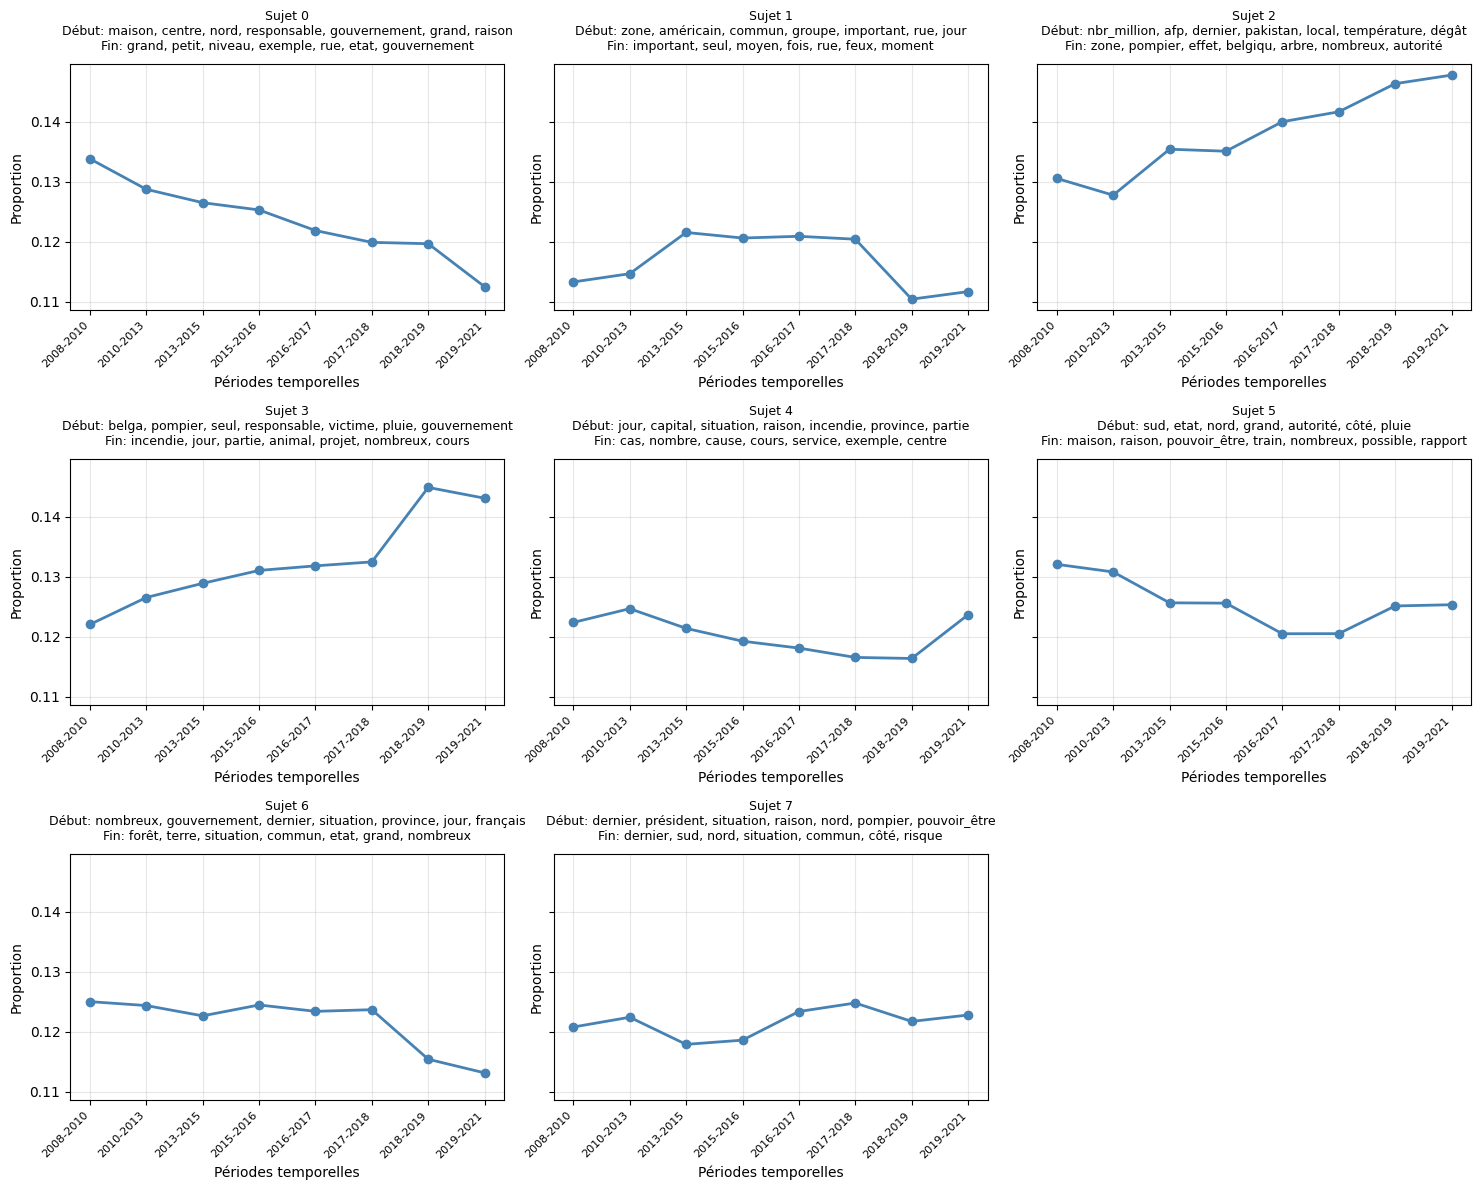

In [98]:
import matplotlib.pyplot as plt
import math

# 1. Configuration de la grille (ex: 3 colonnes)
n_topics = dtm_7.k
n_cols = 3
n_rows = math.ceil(n_topics / n_cols)

# 2. Création de la figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharey=True)
axes = axes.flatten() # Pour boucler facilement sur la grille

for topic_id in range(n_topics):
    proportions = []
    
    # Votre logique de calcul pour chaque période
    for t in range(dtm_7.num_timepoints):
        vals = [doc.get_topic_dist()[topic_id] 
                for doc in dtm_7.docs if doc.timepoint == t]
        
        if len(vals) > 0:
            proportions.append(sum(vals)/len(vals))
        else:
            proportions.append(0)

    # 3. Tracé sur la facette correspondante
        # 3. Tracé sur la facette correspondante
    ax = axes[topic_id]
    ax.plot(proportions, marker='o', linewidth=2, color='steelblue')
    
    # --- MODIFICATION ICI : AJUSTEMENT DES PÉRIODES ---
    ax.set_xticks(range(len(labels_periodes))) # Positionne un tick par période
    ax.set_xticklabels(labels_periodes, rotation=45, ha='right', fontsize=8) 
    
    # Optionnel : Ajout des mots clés dans le titre
    words_start = [w for w, p in dtm_7.get_topic_words(topic_id, timepoint=0, top_n=7)]
    words_end = [w for w, p in dtm_7.get_topic_words(topic_id, timepoint=dtm_7.num_timepoints-1, top_n=7)]
    
    title = (f"Sujet {topic_id}\n"
             f"Début: {', '.join(words_start)}\n"
             f"Fin: {', '.join(words_end)}")
    
    ax.set_title(title, fontsize=9, pad=10)
    ax.set_xlabel("Périodes temporelles") # Plus précis que "Time"
    ax.set_ylabel("Proportion")
    ax.grid(True, alpha=0.3)


# 4. Nettoyage : enlever les graphiques vides si K n'est pas un multiple de 3
for i in range(topic_id + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [99]:
import pandas as pd

def analyse_semantic_drift(dtm_7, top_n=25):
    drift_data = []

    for k in range(dtm_7.k):
        for t in range(dtm_7.num_timepoints - 1):
            # Récupérer les mots à T et T+1
            words_t = set([w for w, p in dtm_7.get_topic_words(k, timepoint=t, top_n=top_n)])
            words_t_next = set([w for w, p in dtm_7.get_topic_words(k, timepoint=t+1, top_n=top_n)])
            
            # Calculer les intersections et les nouveaux mots
            communs = words_t.intersection(words_t_next)
            nouveaux = words_t_next - words_t
            disparus = words_t - words_t_next
            
            # Taux de renouvellement (0 = stable, 1 = 100% nouveau)
            turnover = len(nouveaux) / top_n
            
            drift_data.append({
                "Sujet": k,
                "Transition": f"T{t} -> T{t+1}",
                "Taux_Renouvellement": turnover,
                "Mots_Restants": len(communs),
                "Nouveaux_Mots": ", ".join(list(nouveaux)[:9]), # Top 5 des nouveaux
                "Mots_Sortants": ", ".join(list(disparus)[:9])
            })

    return pd.DataFrame(drift_data)

# --- Exécution et Affichage ---
df_drift = analyse_semantic_drift(dtm_7)

# affiche les moments où le changement est le plus fort (> 20%)
print("--- Alertes de mutations sémantiques (> 25% de changement) ---")
display(df_drift[df_drift['Taux_Renouvellement'] > 0.25])


--- Alertes de mutations sémantiques (> 25% de changement) ---


,Sujet,Transition,Taux_Renouvellement,Mots_Restants,Nouveaux_Mots,Mots_Sortants
4,0,T4 -> T5,0.48,13,"responsable, exemple, population, nbr_million, côté, autorité, orage, température, agriculteur","rapport, pluie, zone, incendie, raison, village, américain, jusqu, voiture"
9,1,T2 -> T3,0.32,17,"sud, bon, travail, raison, moyen, ouest, centre, cas","train, afp, pouvoir_être, côté, situation, service, route, total"
10,1,T3 -> T4,0.28,18,"nbr_million, situation, moment, dernier, mois, lieu, route","rapport, cas, sud, village, raison, ouest, jour"
11,1,T4 -> T5,0.28,18,"responsable, rapport, tel, température, public, fois, bruxelle","zone, nbr_million, autorité, petit, mois, commun, route"
25,3,T4 -> T5,0.32,17,"animal, raison, vie, température, arbre, bruxelle, projet, chaleur","zone, village, cause, gouvernement, seul, victime, ouest, centre"
30,4,T2 -> T3,0.28,18,"exemple, pouvoir_être, sud, gouvernement, service, important, centre","neige, situation, part, voiture, victime, commun, jour"
33,4,T5 -> T6,0.36,16,"responsable, mesure, possible, moment, climat, fois, mois, rue, terrain","pouvoir_être, incendie, temps, raison, culture, nord, politique, local, suite"
36,5,T1 -> T2,0.28,18,"rapport, typhon, pouvoir_être, village, fois, victime, centre","zone, président, site, partie, service, cours, total"
37,5,T2 -> T3,0.28,18,"mesure, train, zone, site, cours, lieu, maison","typhon, village, temps, situation, petit, fois, victime"
45,6,T3 -> T4,0.28,18,"village, forêt, agriculteur, politique, rue, moyen, centre","rapport, sud, petit, grand, météo, cas, enfant"


In [126]:
exec(open("causes_vs_consequences_final.py").read())
# → affiche : "Fonctions chargées : ..."

df_lda = extraire_lda(best_lda_model_7, new_corpus, df_select_trie2, LDA_ASSIGNATION)
df_dtm = extraire_dtm(dtm_7, DTM_ASSIGNATION)

Fonctions chargées : extraire_lda, extraire_dtm, extraire_bert, extraire_bert_dynamique, tracer_graphique


In [125]:
# À la fin de lda_model.ipynb
import pickle
pickle.dump({"lda": df_lda, "dtm": df_dtm}, open("df_causes.pkl", "wb"))